In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

In [ ]:
# Define all subdirectories in nixround (short-run notebook)
nixround_base = Path('../experiment_results/nixround')

def resolve_dataset_path(base, *candidates):
    for rel in candidates:
        candidate = base / rel
        if candidate.exists():
            return candidate
    # Keep notebook runnable even if folders are not present yet.
    return base / candidates[0]

subdirs = {
    'base_linux': resolve_dataset_path(nixround_base, 'linux_short_base_nix'),
    'base_unikernel': resolve_dataset_path(nixround_base, 'unikernel_short_base_nix'),
    'naive_linux': resolve_dataset_path(nixround_base, 'linux_naive_short'),
    'linux_iso': resolve_dataset_path(nixround_base, 'linux_short_ISO_nix'),
    'linux_optimized_wo_iso': resolve_dataset_path(nixround_base, 'linux_short_OPT_nix'),
    'optimized_unikernel': resolve_dataset_path(nixround_base, 'unikernel_short_OPT_nix'),
}

config_labels = {
    'base_linux': 'Linux Base',
    'naive_linux': 'Linux Naive',
    'linux_iso': 'Linux Iso',
    'linux_optimized_wo_iso': 'Linux Opt',
    'base_unikernel': 'Unikernel Base',
    'optimized_unikernel': 'Unikernel Opt',
}
# Compatibility alias if referenced with this spelling elsewhere
config_lables = config_labels

print('Available subdirectories:')
for name, path in subdirs.items():
    pretty = config_labels.get(name, name)
    exists = 'exists' if path.exists() else 'missing'
    print(f'  {pretty}: {path} ({exists})')

Available subdirectories:
  Linux Base: nixround/linux_short_base_nix (exists)
  Unikernel Base: nixround/unikernel_short_base_nix (exists)
  Linux Naive: nixround/linux_naive_short (exists)
  Linux Iso: nixround/linux_short_ISO_nix (exists)
  Linux Opt: nixround/linux_short_OPT_nix (exists)
  Unikernel Opt: nixround/unikernel_short_OPT_nix (exists)


In [69]:
# Load powermeter measurements (binary_output_*.log files)
powermeter_data = {}

for name, path in subdirs.items():
    powermeter_data[name] = {}
    
    # Get all .log files in the directory
    log_files = sorted(path.glob('binary_output_*.log'))
    
    for log_file in log_files:
        # Extract benchmark name and iteration number from filename
        # e.g., binary_output_crc32_0.log -> benchmark=crc32, iteration=0
        match = re.match(r'binary_output_(.+)_(\d+)\.log', log_file.name)
        if match:
            benchmark = match.group(1)
            iteration = int(match.group(2))
            
            # Initialize benchmark dict if needed
            if benchmark not in powermeter_data[name]:
                powermeter_data[name][benchmark] = {}
            
            # Load the log file
            try:
                df = pd.read_csv(log_file)
                powermeter_data[name][benchmark][iteration] = df
            except Exception as e:
                print(f"Error loading {log_file}: {e}")

# Print summary
print("Powermeter data summary:")
for config_name, benchmarks in powermeter_data.items():
    total_files = sum(len(iterations) for iterations in benchmarks.values())
    print(f"  {config_name}: {len(benchmarks)} benchmarks, {total_files} total files")

Powermeter data summary:
  base_linux: 9 benchmarks, 450 total files
  base_unikernel: 9 benchmarks, 450 total files
  naive_linux: 9 benchmarks, 450 total files
  linux_iso: 9 benchmarks, 450 total files
  linux_optimized_wo_iso: 9 benchmarks, 450 total files
  optimized_unikernel: 9 benchmarks, 450 total files


In [70]:
# Display sample powermeter data
config = 'base_linux'
benchmark = list(powermeter_data[config].keys())[0] if powermeter_data[config] else None
iteration = 0

if config in powermeter_data and benchmark in powermeter_data[config]:
    if iteration in powermeter_data[config][benchmark]:
        print(f"Sample powermeter data from {config} / {benchmark} / iteration {iteration}:")
        print(powermeter_data[config][benchmark][iteration].head(10))
        print(f"\nShape: {powermeter_data[config][benchmark][iteration].shape}")
    else:
        print(f"Iteration {iteration} not found")
else:
    print(f"Config or benchmark not found")

Sample powermeter data from base_linux / crc32 / iteration 0:
     unix_timestamp  active_power (mW)
0  1774519943966026              49560
1  1774519944009032              49560
2  1774519944051982              49560
3  1774519944094866             390080

Shape: (4, 2)


In [71]:
# Display structure of powermeter data
print("Benchmarks found per configuration:")
for config_name, benchmarks in powermeter_data.items():
    benchmark_list = sorted(benchmarks.keys())
    iterations = [len(benchmarks[b]) for b in benchmark_list]
    print(f"\n{config_name}:")
    print(f"  Benchmarks: {benchmark_list}")
    print(f"  Iterations per benchmark: {iterations[0] if iterations else 0} (first benchmark)")

Benchmarks found per configuration:

base_linux:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

base_unikernel:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

naive_linux:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

linux_iso:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

linux_optimized_wo_iso:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

optimized_unikernel:
  Benchmark

In [72]:
# Load PC measurements (unikernel_output.csv from each directory)
pc_data = {}

for name, path in subdirs.items():
    csv_file = path / 'unikernel_output.csv'
    if csv_file.exists():
        df = pd.read_csv(csv_file)
        pc_data[name] = df
        print(f"Loaded {name}: {len(df)} rows, {len(df.columns)} columns")
    else:
        print(f"Warning: {csv_file} not found")

print(f"\nTotal configurations loaded: {len(pc_data)}")

Loaded base_linux: 450 rows, 21 columns
Loaded base_unikernel: 450 rows, 21 columns
Loaded naive_linux: 450 rows, 21 columns
Loaded linux_iso: 450 rows, 21 columns
Loaded linux_optimized_wo_iso: 450 rows, 21 columns
Loaded optimized_unikernel: 450 rows, 21 columns

Total configurations loaded: 6


In [73]:
# Display sample PC data for one configuration
if pc_data:
    first_config = list(pc_data.keys())[0]
    print(f"Sample PC data from {first_config}:")
    print(pc_data[first_config].head())

Sample PC data from base_linux:
  benchmark  cpu_cycles   cycles_start     cycles_end      time_ns  \
0     crc32   436219654  5753631552143  5754067771797  141310510.0   
1     crc32   436282041  5754068779582  5754505061623  141313817.0   
2     crc32   436394750  5754506041489  5754942436239  141336759.0   
3     crc32   436764837  5754943346086  5755380110923  141403680.0   
4     crc32   436633711  5755380872450  5755817506161  141359622.0   

      time_ms  cooldown_ms  temp_before  temp_after  pkg_temp_before  ...  \
0  141.310510        0.060         34.0        34.0             44.0  ...   
1  141.313817        0.018         34.0        34.0             42.0  ...   
2  141.336759        0.016         34.0        34.0             41.0  ...   
3  141.403680        0.016         34.0        34.0             41.0  ...   
4  141.359622        0.016         34.0        34.0             40.0  ...   

   pkg_joules    pkg_mJ  pp0_joules    pp0_mJ  pp1_joules  pp1_mJ  \
0    2.468277  

In [74]:
# Calculate energy consumption from powermeter data and compare with pkg energy
# Energy = Average Power (W) × Time (s)

energy_results = []
required_pc_cols = {'benchmark', 'pkg_joules', 'cpu_cycles'}

for config_name, pc_df in pc_data.items():
    missing_cols = required_pc_cols - set(pc_df.columns)
    if missing_cols:
        print(f"Skipping {config_name}: missing columns {sorted(missing_cols)}")
        continue

    # Group once per config to avoid repeated filtering
    grouped_pc = {
        bench: group.reset_index(drop=True)
        for bench, group in pc_df.groupby('benchmark', sort=False)
    }

    for benchmark, pc_bench in grouped_pc.items():
        if len(pc_bench) == 0:
            continue

        # Calculate mean and std for pkg energy from PC data (in Joules)
        pkg_energies = pc_bench['pkg_joules'].to_numpy()
        mean_pkg_joules = pkg_energies.mean()
        std_pkg_joules = pkg_energies.std()
        mean_time_ms = pc_bench['cpu_cycles'].mean() / 3.1e6  # Convert cycles to ms at 3.1 GHz

        # Calculate energy from powermeter data if available
        pm_bench = powermeter_data.get(config_name, {}).get(benchmark, {})
        if pm_bench:
            powermeter_energies = []
            cpu_cycles = pc_bench['cpu_cycles'].to_numpy()

            for iteration, pm_df in pm_bench.items():
                # Skip empty/small DataFrames and out-of-range iterations
                if len(pm_df) < 2 or iteration >= len(cpu_cycles):
                    continue
                if 'active_power (mW)' not in pm_df.columns:
                    continue

                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                time_span_s = cpu_cycles[iteration] / 3.1e9  # Convert cycles to seconds at 3.1 GHz
                powermeter_energies.append(avg_power_w * time_span_s)

            mean_powermeter_energy = np.mean(powermeter_energies) if powermeter_energies else None
            std_powermeter_energy = np.std(powermeter_energies) if powermeter_energies else None
        else:
            mean_powermeter_energy = None
            std_powermeter_energy = None

        energy_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pkg_energy_j': mean_pkg_joules,
            'pkg_energy_std': std_pkg_joules,
            'powermeter_energy_j': mean_powermeter_energy,
            'powermeter_energy_std': std_powermeter_energy,
            'time_ms': mean_time_ms
        })

# Convert to DataFrame for easier plotting
energy_df = pd.DataFrame(energy_results)
print(f"Energy analysis ready: {len(energy_df)} benchmark-config combinations")
print(energy_df.head(10))

Energy analysis ready: 54 benchmark-config combinations
           config      benchmark  pkg_energy_j  pkg_energy_std  \
0      base_linux          crc32      2.463678        0.008019   
1      base_linux          cubic      2.177124        0.017907   
2      base_linux       dijkstra      2.689505        0.011275   
3      base_linux           fdct      2.672920        0.010832   
4      base_linux            fir      2.551703        0.010742   
5      base_linux  matmult-float      3.206166        0.021218   
6      base_linux    matmult-int      2.920107        0.017621   
7      base_linux  nettle-sha256      3.380240        0.022361   
8      base_linux       rijndael      3.181606        0.009634   
9  base_unikernel          crc32      2.193142        0.007318   

   powermeter_energy_j  powermeter_energy_std     time_ms  
0             6.570992               1.768913  140.755822  
1             5.420045               0.018975  114.936216  
2             6.402535               

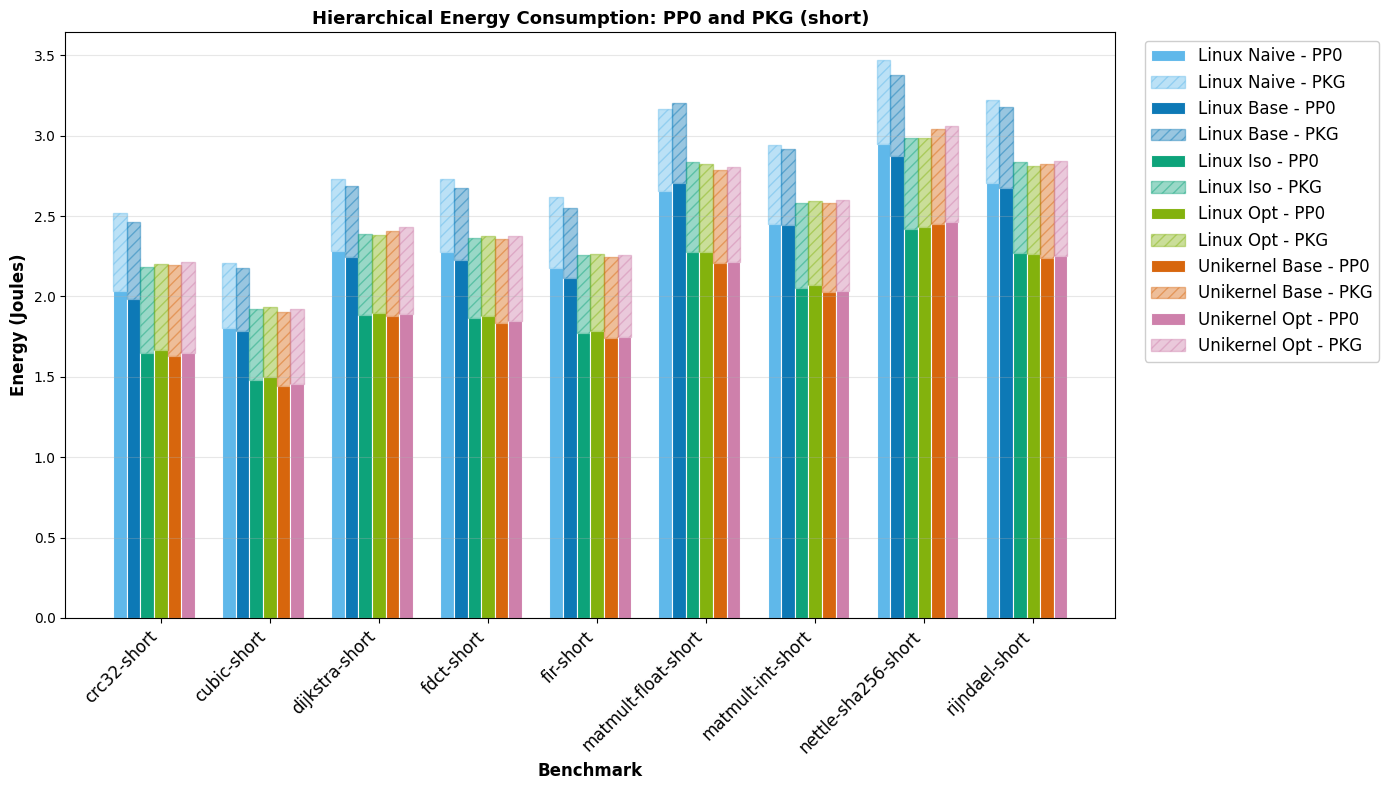

In [75]:
# Create plot showing hierarchical energy consumption: PP0 + Uncore = PKG
# PP0 (CPU cores) is a subset of PKG; the difference is shown as Uncore
fig, ax = plt.subplots(figsize=(14, 8))

# Get unique benchmarks and configs (filter out NaN values)
benchmarks = sorted([b for b in energy_df['benchmark'].unique() if pd.notna(b)])

# Define custom order for configs
config_order = [
    'naive_linux',
    'base_linux',
    'linux_iso',
    'linux_optimized_wo_iso',
    'base_unikernel',
    'optimized_unikernel'
]
# Filter to only configs present in data, maintaining the desired order
configs = [c for c in config_order if c in energy_df['config'].unique()]

# Use global config label mapping
config_names = config_labels

# Use the same config color mapping as CV plots
config_colors = {
    'base_linux': '#0072B2',
    'naive_linux': '#56B4E9',
    'linux_iso': '#009E73',
    'linux_optimized_wo_iso': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}

# Set up x positions for grouped bars
x = np.arange(len(benchmarks)) * 1.2
width = 0.15

# Plot bars for each configuration
for i, config in enumerate(configs):
    config_data = energy_df[energy_df['config'] == config]
    short_name = config_names.get(config, config)
    bar_color = config_colors.get(config, '#7f7f7f')
    
    # Prepare data aligned with benchmark order
    pkg_energies = []
    pp0_energies = []
    uncore_energies = []
    
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0:
            pkg_val = bench_data['pkg_energy_j'].values[0]
            # Get PP0 data from pc_data
            if config in pc_data:
                pc_bench = pc_data[config][pc_data[config]['benchmark'] == bench]
                pp0_val = pc_bench['pp0_joules'].mean() if len(pc_bench) > 0 else 0
            else:
                pp0_val = 0
            
            # Handle None values and derive Uncore = PKG - PP0
            pkg_clean = pkg_val if pd.notna(pkg_val) else 0
            pp0_clean = pp0_val if pd.notna(pp0_val) else 0
            uncore_clean = max(pkg_clean - pp0_clean, 0)
            
            pkg_energies.append(pkg_clean)
            pp0_energies.append(pp0_clean)
            uncore_energies.append(uncore_clean)
        else:
            pkg_energies.append(0)
            pp0_energies.append(0)
            uncore_energies.append(0)
    
    # Plot stacked bars to make transition explicit:
    # - PP0 core energy (base)
    # - Uncore = PKG - PP0 (hatched top layer)
    offset = (i - len(configs)/2) * width
    
    ax.bar(
        x + offset,
        pp0_energies,
        width,
        label=f'{short_name} - PP0',
        color=bar_color,
        alpha=0.95,
        edgecolor='white',
        linewidth=0.8
    )
    
    ax.bar(
        x + offset,
        uncore_energies,
        width,
        bottom=pp0_energies,
        label=f'{short_name} - PKG',
        color=bar_color,
        alpha=0.4,
        edgecolor=bar_color,
        linewidth=1.0,
        hatch='///'
    )

ax.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
ax.set_title('Hierarchical Energy Consumption: PP0 and PKG (short)', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{b}-short' for b in benchmarks], rotation=45, ha='right', fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, ncol=1, framealpha=0.95)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [76]:
# Calculate coefficient of variation (CV) for energy measurements
# CV = (std / mean) * 100%

cv_results = []

for config_name in subdirs.keys():
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get all PKG energy values for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        pkg_energies = pc_bench['pkg_joules'].values
        
        # Calculate PKG CV
        if len(pkg_energies) > 1:
            pkg_cv = (pkg_energies.std() / pkg_energies.mean()) * 100
        else:
            pkg_cv = None
        
        # Calculate powermeter CV if available
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            powermeter_energies = []
            
            for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                if len(pm_df) < 2:
                    continue
                
                # Skip if iteration index is out of bounds
                if iteration >= len(pc_bench):
                    continue
                
                time_span_s = pc_bench.iloc[iteration]['cpu_cycles'] / 3.1e9  # Convert cycles to seconds at 3.1 GHz

                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                energy_j = avg_power_w * time_span_s
                powermeter_energies.append(energy_j)
            
            if len(powermeter_energies) > 1:
                pm_cv = (np.std(powermeter_energies) / np.mean(powermeter_energies)) * 100
            else:
                pm_cv = None
        else:
            pm_cv = None
        
        cv_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pkg_cv': pkg_cv,
            'powermeter_cv': pm_cv
        })

# Convert to DataFrame
cv_df = pd.DataFrame(cv_results)
print(f"CV analysis ready: {len(cv_df)} benchmark-config combinations")
print(cv_df.head(10))

CV analysis ready: 54 benchmark-config combinations
           config      benchmark    pkg_cv  powermeter_cv
0      base_linux          crc32  0.325493      26.920030
1      base_linux          cubic  0.822511       0.350087
2      base_linux       dijkstra  0.419234       0.355747
3      base_linux           fdct  0.405250       0.322422
4      base_linux            fir  0.420978       0.216170
5      base_linux  matmult-float  0.661791       0.610322
6      base_linux    matmult-int  0.603446       1.511997
7      base_linux  nettle-sha256  0.661529       0.786298
8      base_linux       rijndael  0.302798       0.203219
9  base_unikernel          crc32  0.333679       0.274767


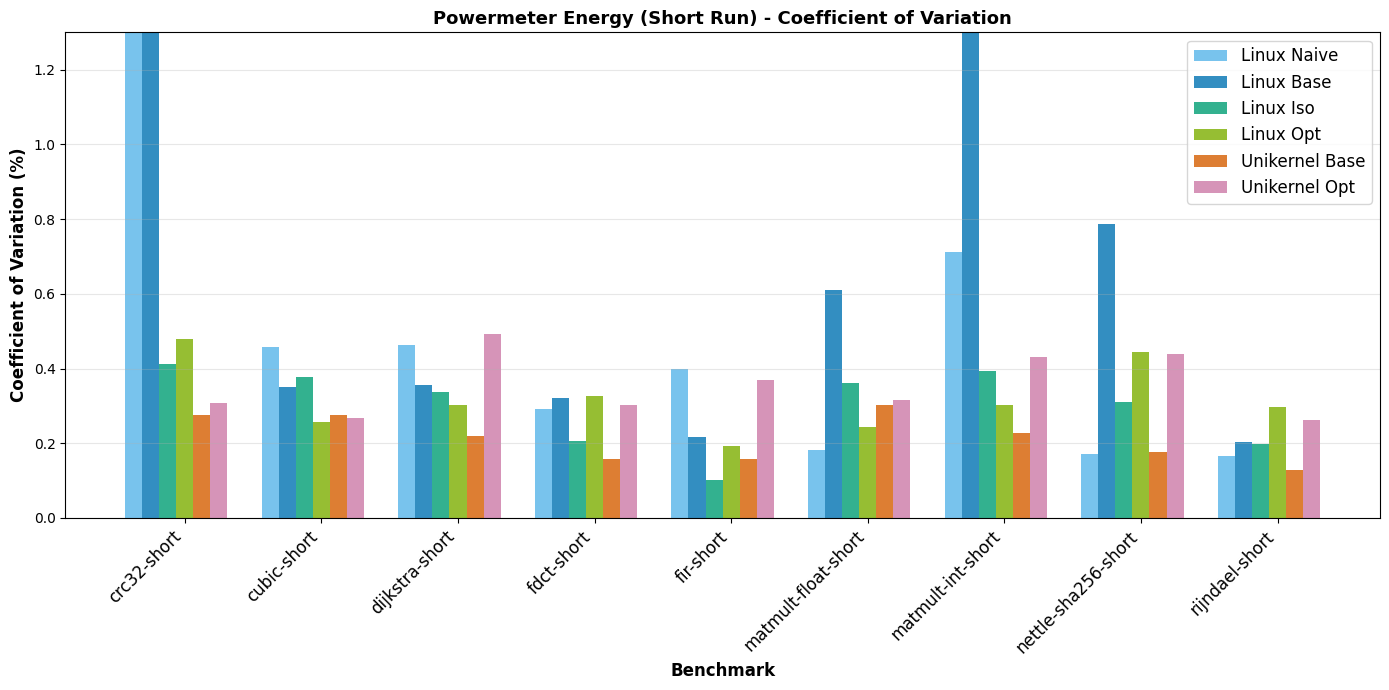

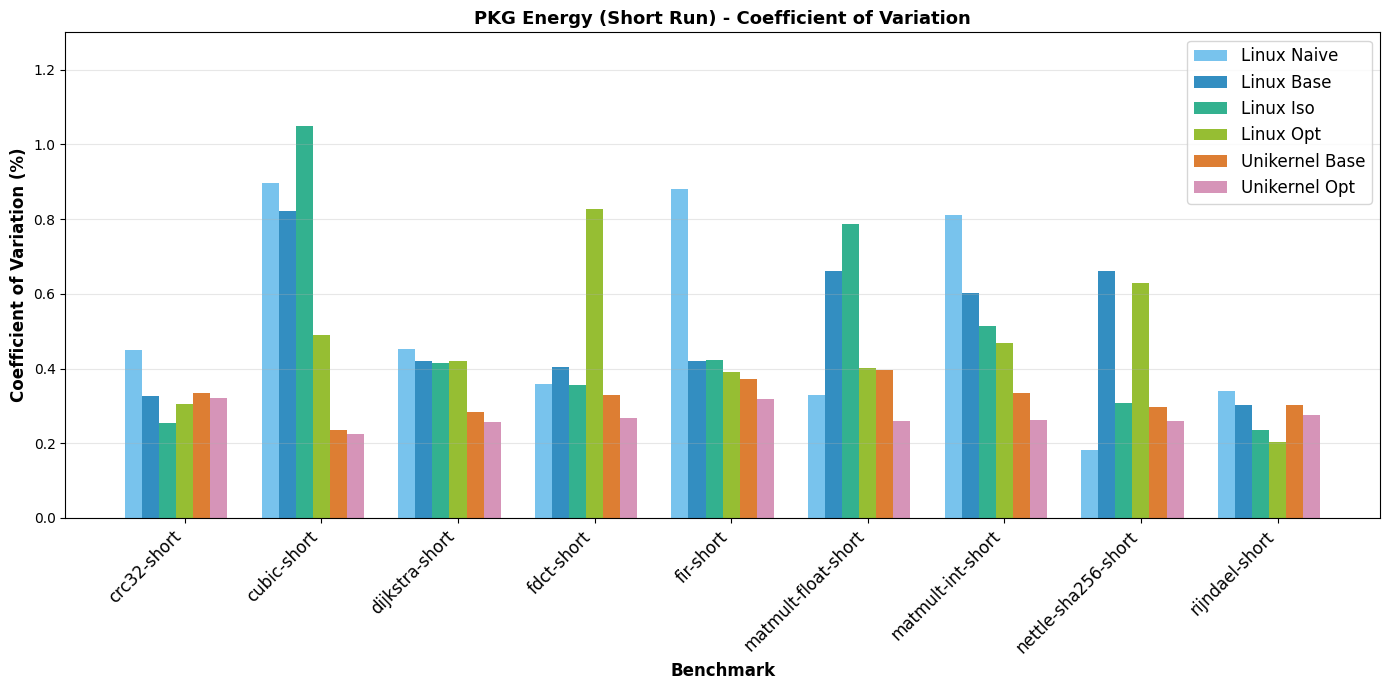

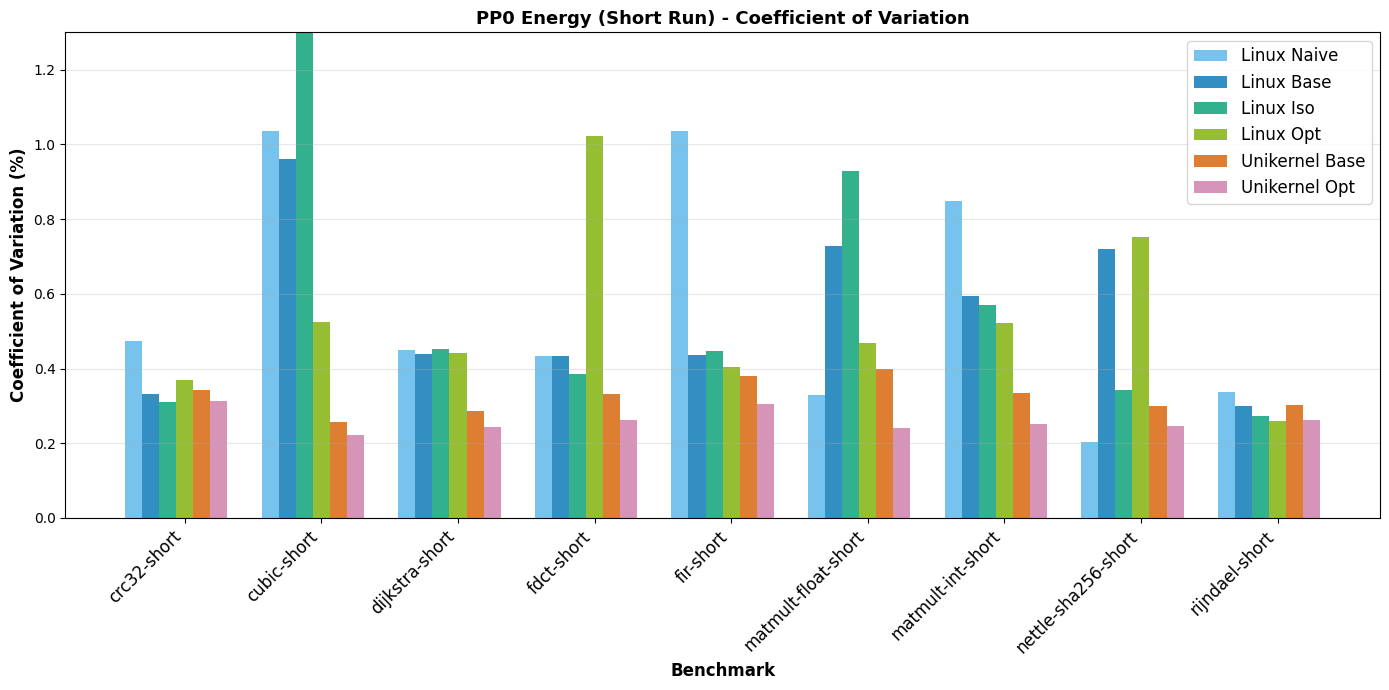

In [77]:
# Create three separate plots for coefficient of variation
# Get unique benchmarks and configs
benchmarks = sorted([b for b in cv_df['benchmark'].unique() if pd.notna(b)])

# Define custom order for configs
config_order = [
    'naive_linux',
    'base_linux',
    'linux_iso',
    'linux_optimized_wo_iso',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in cv_df['config'].unique()]

# Set up x positions with extra spacing between benchmark groups
x = np.arange(len(benchmarks)) * 1.2
width = 0.15
config_colors = {
    'base_linux': '#0072B2',
    'naive_linux': '#56B4E9',
    'linux_iso': '#009E73',
    'linux_optimized_wo_iso': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}


# Plot 1: Powermeter CV
fig1, ax1 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = cv_df[cv_df['config'] == config]
    display_name = config_labels.get(config, config)
    
    pm_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['powermeter_cv'].values[0]):
            pm_cvs.append(bench_data['powermeter_cv'].values[0])
        else:
            pm_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax1.bar(x + offset, pm_cvs, width, label=display_name, color=config_colors.get(config, '#7f7f7f'), alpha=0.8)

ax1.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax1.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax1.set_title('Powermeter Energy (Short Run) - Coefficient of Variation', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{b}-short' for b in benchmarks], rotation=45, ha='right', fontsize=12)
ax1.legend(fontsize=12)
ax1.set_ylim(top=1.3)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: PKG CV
fig2, ax2 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = cv_df[cv_df['config'] == config]
    display_name = config_labels.get(config, config)
    
    pkg_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['pkg_cv'].values[0]):
            pkg_cvs.append(bench_data['pkg_cv'].values[0])
        else:
            pkg_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax2.bar(x + offset, pkg_cvs, width, label=display_name, color=config_colors.get(config, '#7f7f7f'), alpha=0.8)

ax2.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax2.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax2.set_title('PKG Energy (Short Run) - Coefficient of Variation', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{b}-short' for b in benchmarks], rotation=45, ha='right', fontsize=12)
ax2.legend(fontsize=12)
ax2.set_ylim(top=1.3)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: PP0 CV
# Calculate PP0 CV results
pp0_cv_results = []

for config_name in subdirs.keys():
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get all PP0 energy values for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        pp0_energies = pc_bench['pp0_joules'].values
        
        # Calculate PP0 CV
        if len(pp0_energies) > 1:
            pp0_cv = (pp0_energies.std() / pp0_energies.mean()) * 100
        else:
            pp0_cv = None
        
        pp0_cv_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pp0_cv': pp0_cv
        })

# Convert to DataFrame
pp0_cv_df = pd.DataFrame(pp0_cv_results)

fig3, ax3 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = pp0_cv_df[pp0_cv_df['config'] == config]
    display_name = config_labels.get(config, config)
    
    pp0_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['pp0_cv'].values[0]):
            pp0_cvs.append(bench_data['pp0_cv'].values[0])
        else:
            pp0_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax3.bar(x + offset, pp0_cvs, width, label=display_name, color=config_colors.get(config, '#7f7f7f'), alpha=0.8)

ax3.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax3.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax3.set_title('PP0 Energy (Short Run) - Coefficient of Variation', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f'{b}-short' for b in benchmarks], rotation=45, ha='right', fontsize=12)
ax3.legend(fontsize=12)
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(top=1.3)
plt.tight_layout()
plt.show()

Saved: boxplots_short/pkg/boxplot_pkg_crc32.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/2185171842.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


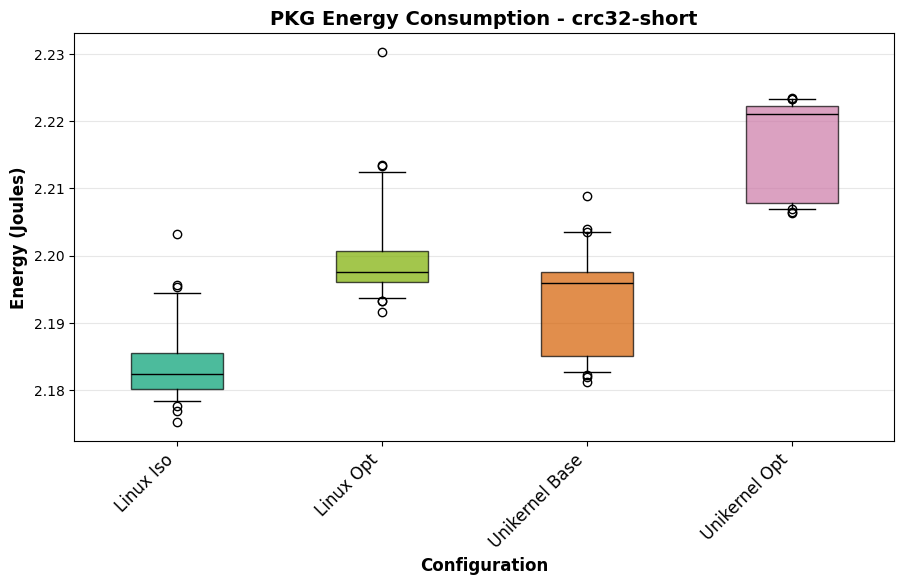

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/2185171842.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/pkg/boxplot_pkg_cubic.png


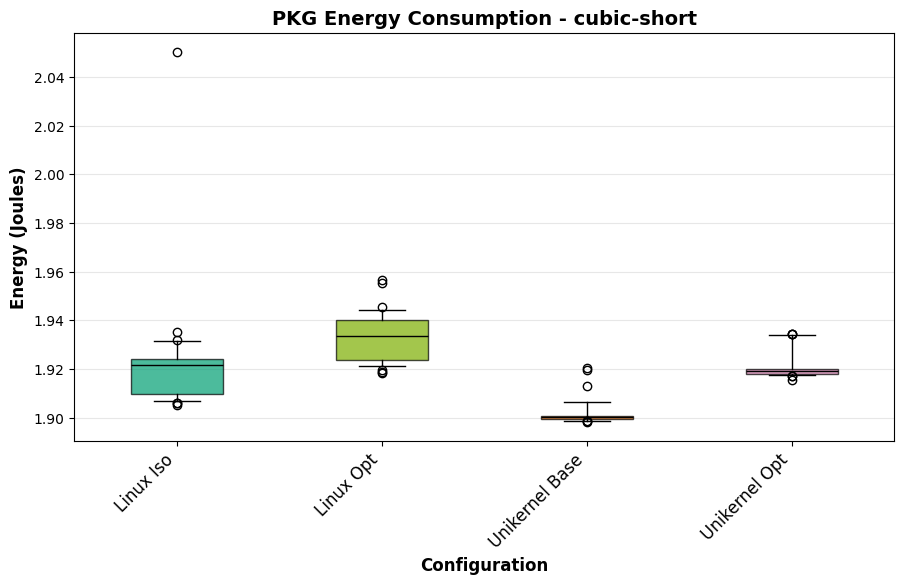

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/2185171842.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/pkg/boxplot_pkg_dijkstra.png


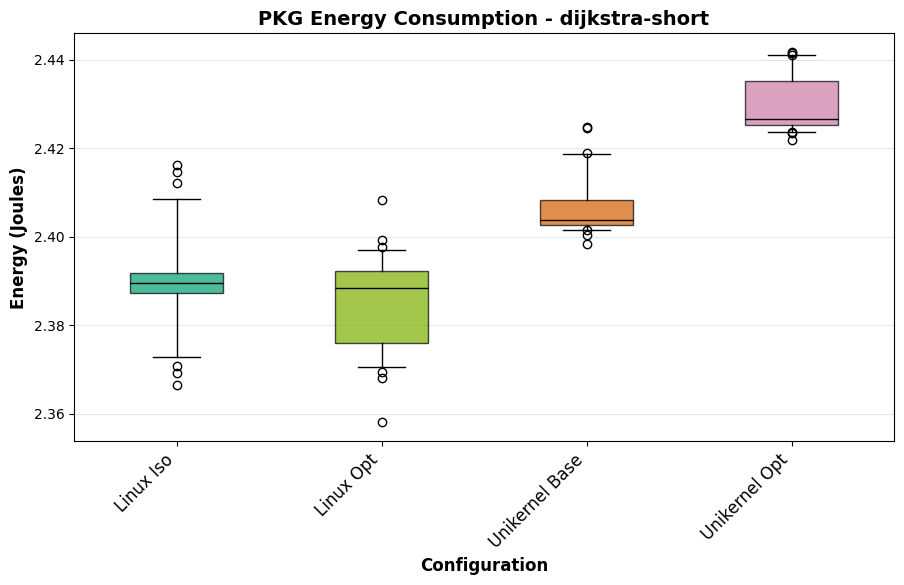

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/2185171842.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/pkg/boxplot_pkg_fdct.png


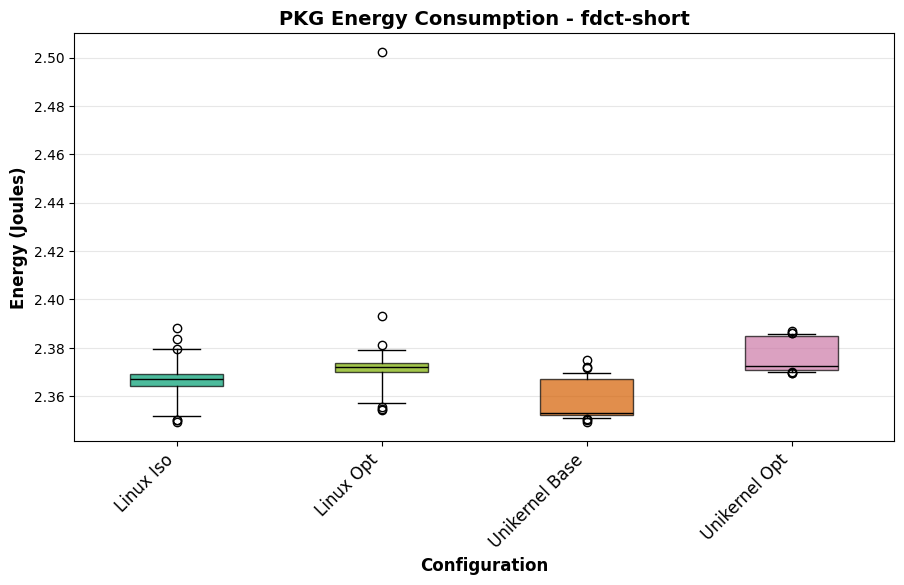

Saved: boxplots_short/pkg/boxplot_pkg_fir.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/2185171842.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


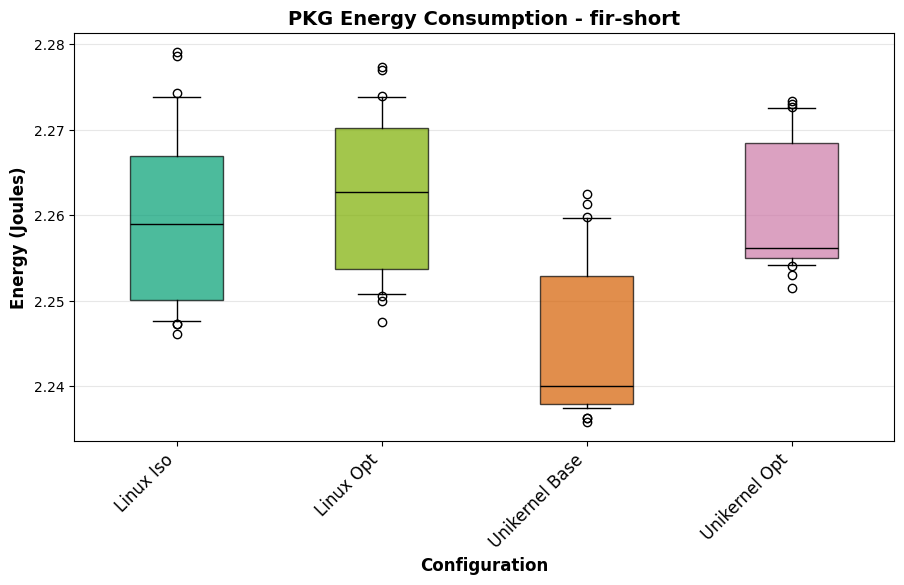

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/2185171842.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/pkg/boxplot_pkg_matmult-float.png


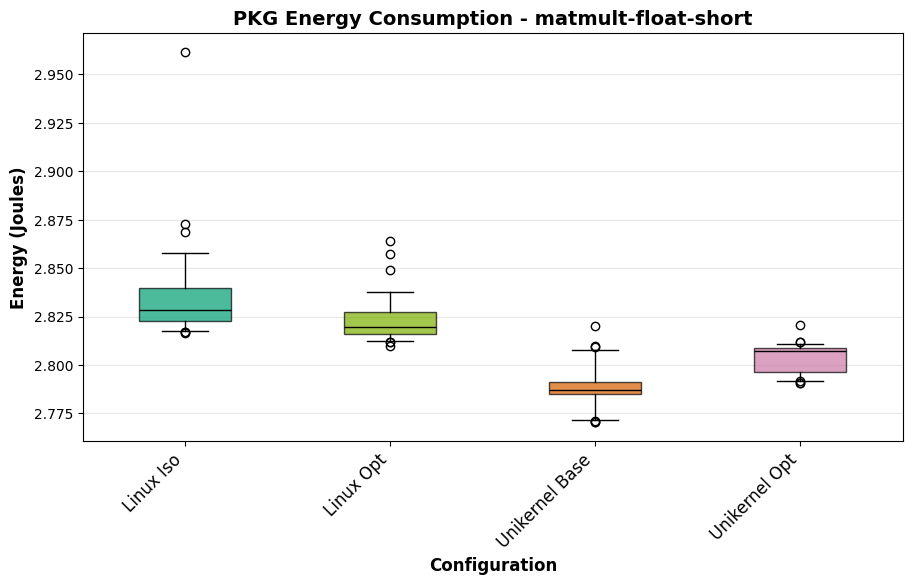

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/2185171842.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/pkg/boxplot_pkg_matmult-int.png


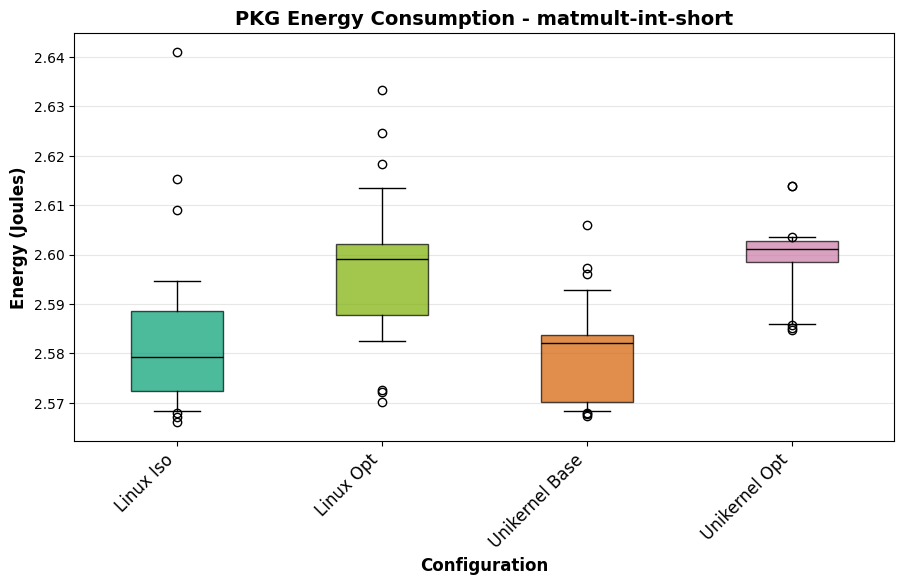

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/2185171842.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/pkg/boxplot_pkg_nettle-sha256.png


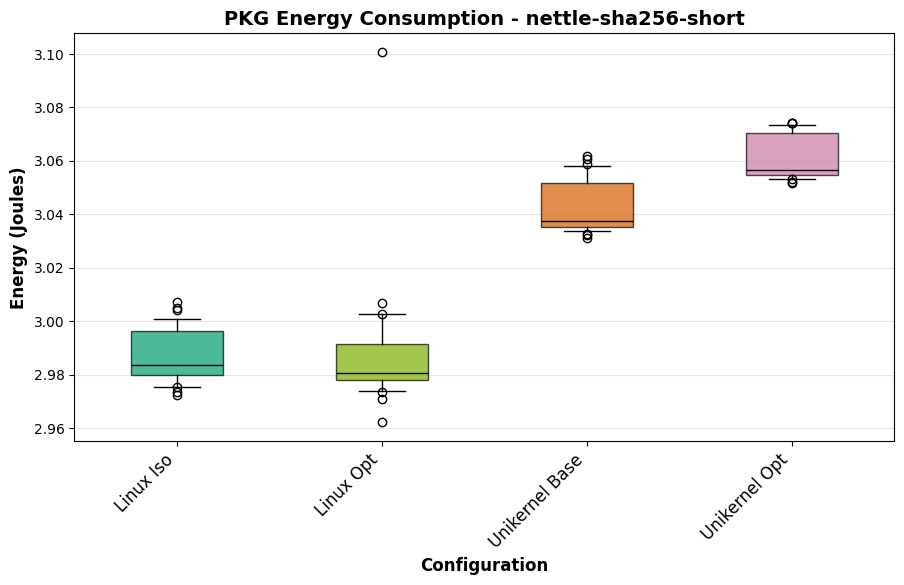

Saved: boxplots_short/pkg/boxplot_pkg_rijndael.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/2185171842.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


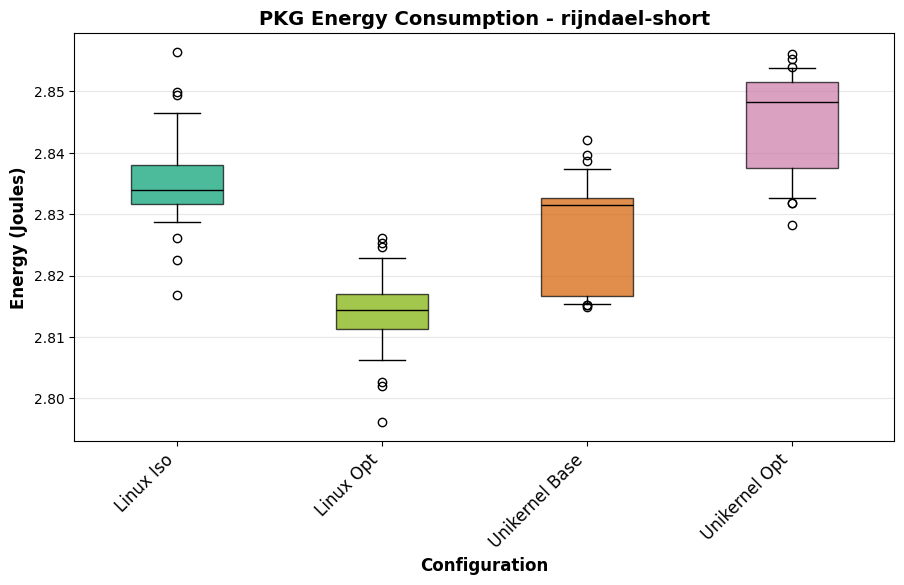

In [78]:
# Boxplot for PKG energy consumption per benchmark
# One plot per benchmark, showing all configurations

# Get unique benchmarks
benchmarks = sorted([b for b in energy_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    # 'naive_linux',
    # 'base_linux',
    'linux_iso',
    'linux_optimized_wo_iso',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys()]

# Define colors matching ryddet_plots
config_colors = {
    'base_linux': '#0072B2',
    'naive_linux': '#56B4E9',
    'linux_iso': '#009E73',
    'linux_optimized_wo_iso': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    colors_to_use = []

    for config_name in configs:
        if config_name not in pc_data:
            continue

        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]

        if len(pc_bench) > 0:
            data_to_plot.append(pc_bench['pkg_joules'].values)
            labels.append(config_labels.get(config_name, config_name))
            colors_to_use.append(config_colors.get(config_name, '#7f7f7f'))

    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))

        # Customize boxplot appearance
        for patch, color in zip(bp['boxes'], colors_to_use):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'PKG Energy Consumption - {benchmark}-short', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45, labelsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=12)
        ax.grid(axis='y', alpha=0.3)

        plt.subplots_adjust(left=0.15, bottom=0.25, right=0.97, top=0.93)

        output_dir = Path('boxplots_short/pkg')
        output_dir.mkdir(parents=True, exist_ok=True)
        filename = output_dir / f'boxplot_pkg_{benchmark}.png'
        plt.savefig(filename, dpi=150)
        print(f"Saved: {filename}")

        plt.show()

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1538001532.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/powermeter/boxplot_powermeter_crc32.png


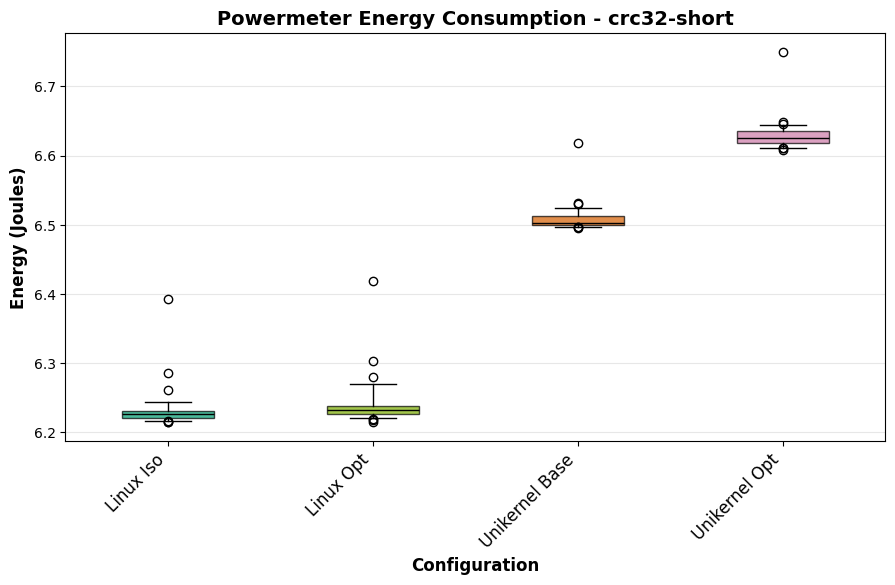

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1538001532.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/powermeter/boxplot_powermeter_cubic.png


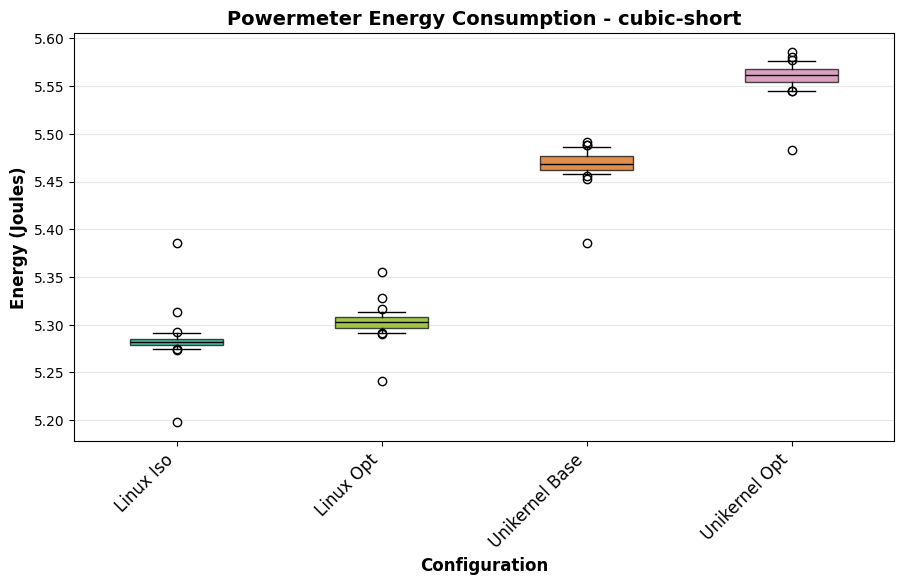

Saved: boxplots_short/powermeter/boxplot_powermeter_dijkstra.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1538001532.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


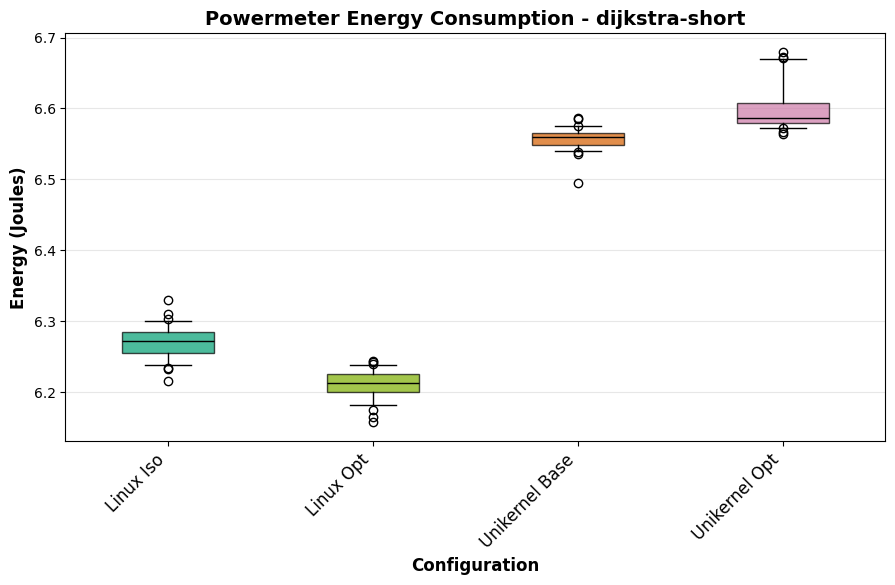

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1538001532.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/powermeter/boxplot_powermeter_fdct.png


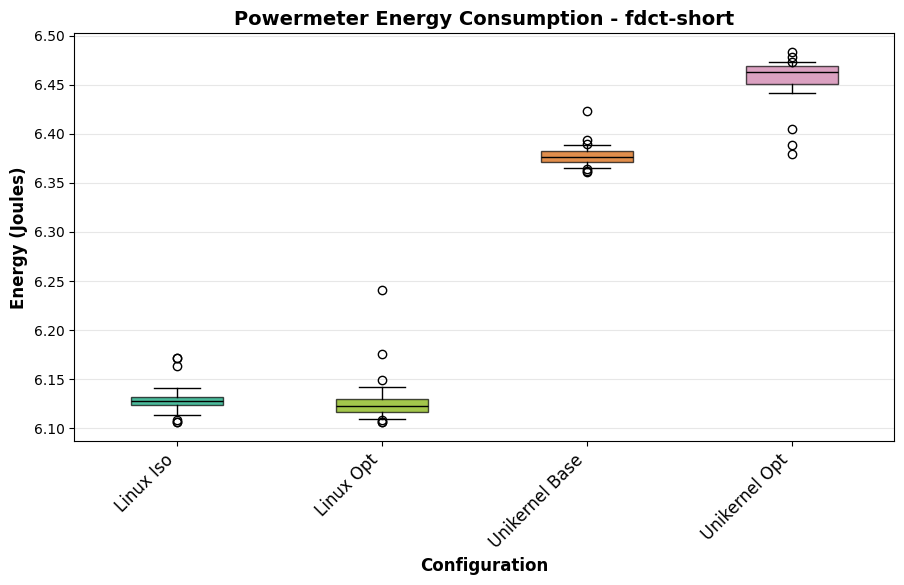

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1538001532.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/powermeter/boxplot_powermeter_fir.png


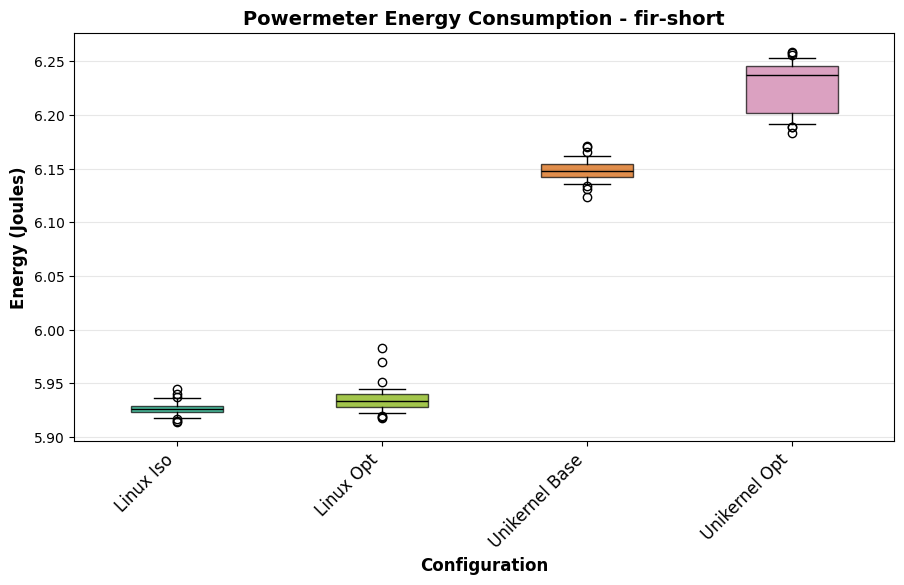

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1538001532.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/powermeter/boxplot_powermeter_matmult-float.png


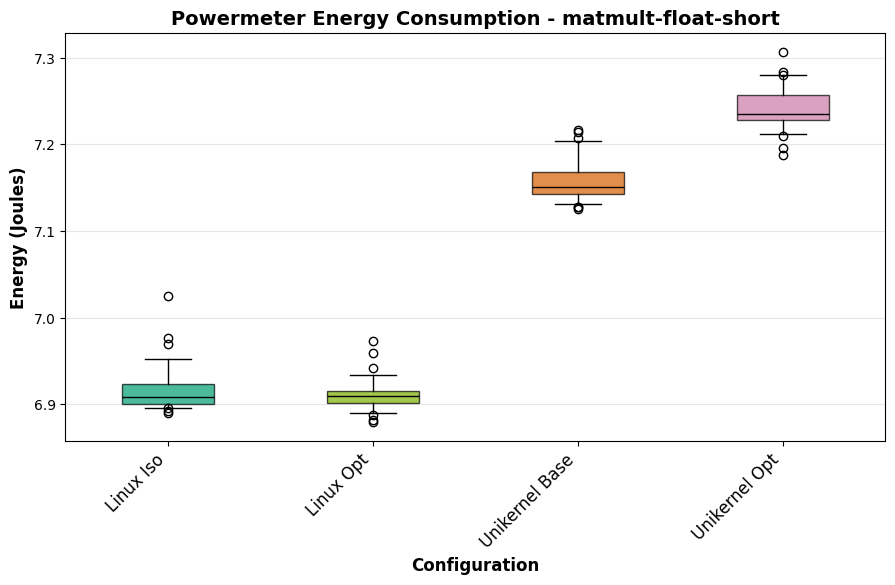

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1538001532.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/powermeter/boxplot_powermeter_matmult-int.png


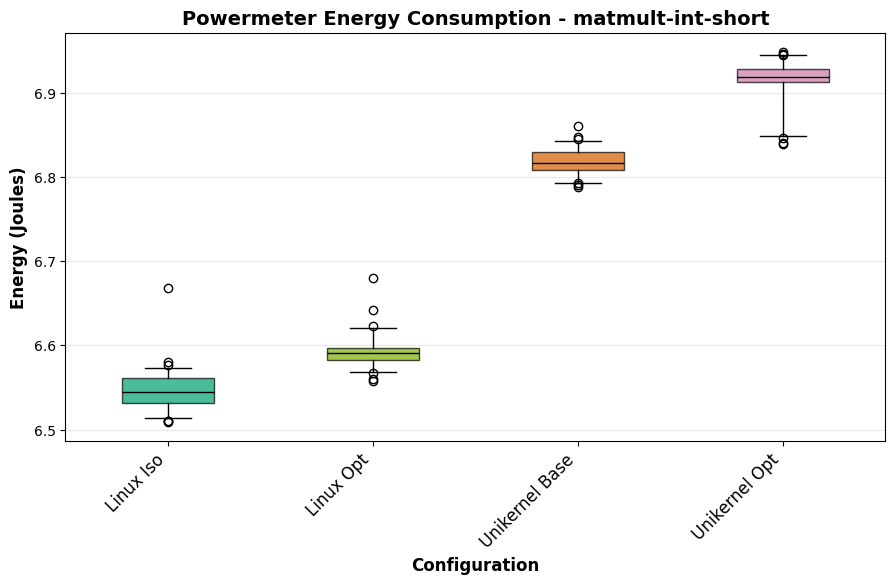

Saved: boxplots_short/powermeter/boxplot_powermeter_nettle-sha256.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1538001532.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


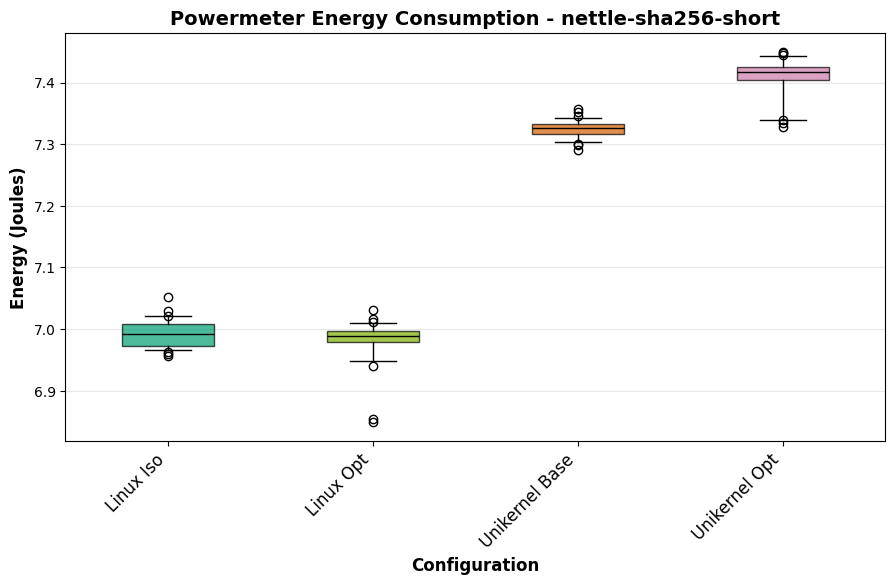

Saved: boxplots_short/powermeter/boxplot_powermeter_rijndael.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1538001532.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


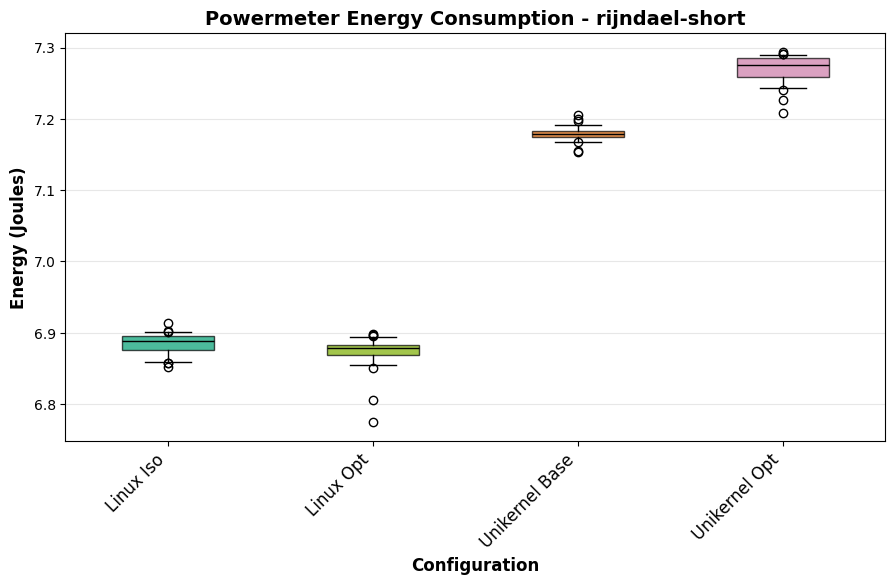

In [79]:
# Boxplot for powermeter energy consumption per benchmark
# One plot per benchmark, showing all configurations

# Get unique benchmarks
benchmarks = sorted([b for b in energy_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    # 'naive_linux',
    # 'base_linux',
    'linux_iso',
    'linux_optimized_wo_iso',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys()]

# Define colors matching ryddet_plots
config_colors = {
    'base_linux': '#0072B2',
    'naive_linux': '#56B4E9',
    'linux_iso': '#009E73',
    'linux_optimized_wo_iso': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    colors_to_use = []

    for config_name in configs:
        bench_data = []

        # Get powermeter data for this config and benchmark
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            if config_name in pc_data:
                pc_df = pc_data[config_name]
                pc_bench = pc_df[pc_df['benchmark'] == benchmark]

                for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                    if len(pm_df) < 2:
                        continue

                    if iteration < len(pc_bench):
                        time_span_s = pc_bench.iloc[iteration]['cpu_cycles'] / 3.1e9  # Convert cycles to seconds at 3.1 GHz
                        avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                        energy_j = avg_power_w * time_span_s
                        bench_data.append(energy_j)

        if bench_data:
            data_to_plot.append(bench_data)
            labels.append(config_labels.get(config_name, config_name))
            colors_to_use.append(config_colors.get(config_name, '#7f7f7f'))

    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))

        # Customize boxplot appearance
        for patch, color in zip(bp['boxes'], colors_to_use):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'Powermeter Energy Consumption - {benchmark}-short', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45, labelsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=12)
        ax.grid(axis='y', alpha=0.3)

        plt.subplots_adjust(left=0.15, bottom=0.25, right=0.97, top=0.93)

        # Create output directory and save figure
        output_dir = Path('boxplots_short/powermeter')
        output_dir.mkdir(parents=True, exist_ok=True)
        filename = output_dir / f'boxplot_powermeter_{benchmark}.png'
        plt.savefig(filename, dpi=150)
        print(f"Saved: {filename}")

        plt.show()

Saved: boxplots_short/time/boxplot_time_crc32.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1507758418.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


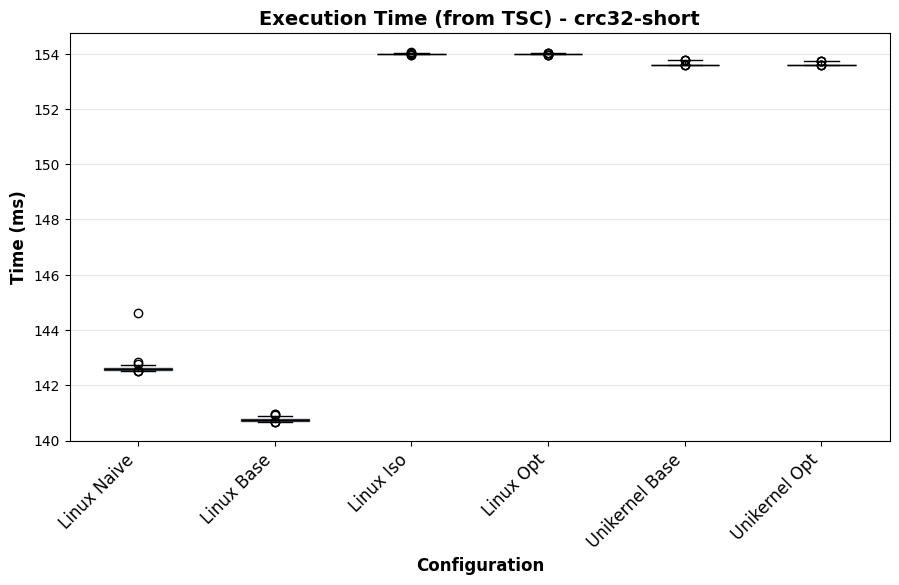


Medians for 'crc32':
  Linux Naive: 142.579474 ms
  Linux Base: 140.727312 ms
  Linux Iso: 153.995326 ms
  Linux Opt: 153.989237 ms
  Unikernel Base: 153.579983 ms
  Unikernel Opt: 153.580382 ms

Median range for 'crc32':
  Smallest: Linux Base: 140.727312 ms
  Largest:  Linux Iso: 153.995326 ms
  Difference: 9.43%

Saved: boxplots_short/time/boxplot_time_cubic.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1507758418.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


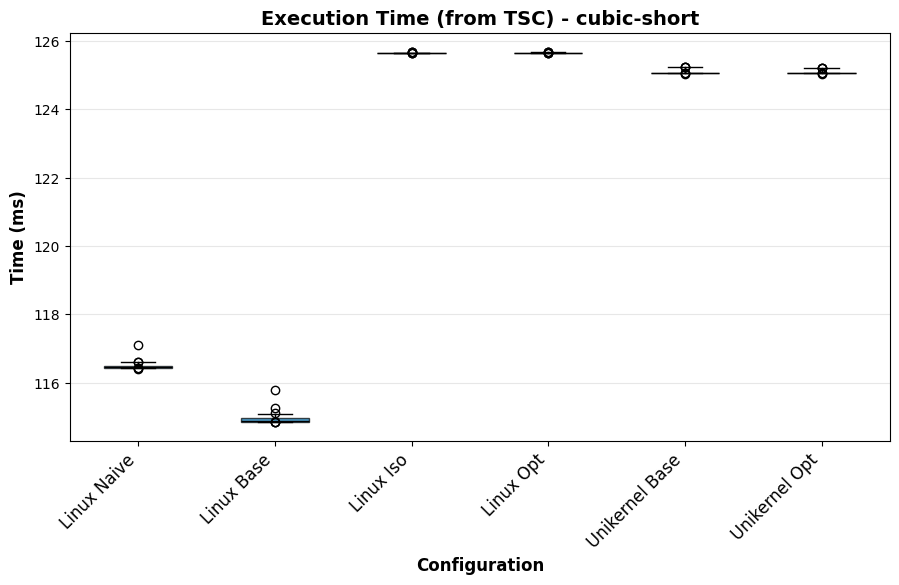


Medians for 'cubic':
  Linux Naive: 116.462310 ms
  Linux Base: 114.875595 ms
  Linux Iso: 125.650537 ms
  Linux Opt: 125.658651 ms
  Unikernel Base: 125.059105 ms
  Unikernel Opt: 125.058551 ms

Median range for 'cubic':
  Smallest: Linux Base: 114.875595 ms
  Largest:  Linux Opt: 125.658651 ms
  Difference: 9.39%



/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1507758418.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/time/boxplot_time_dijkstra.png


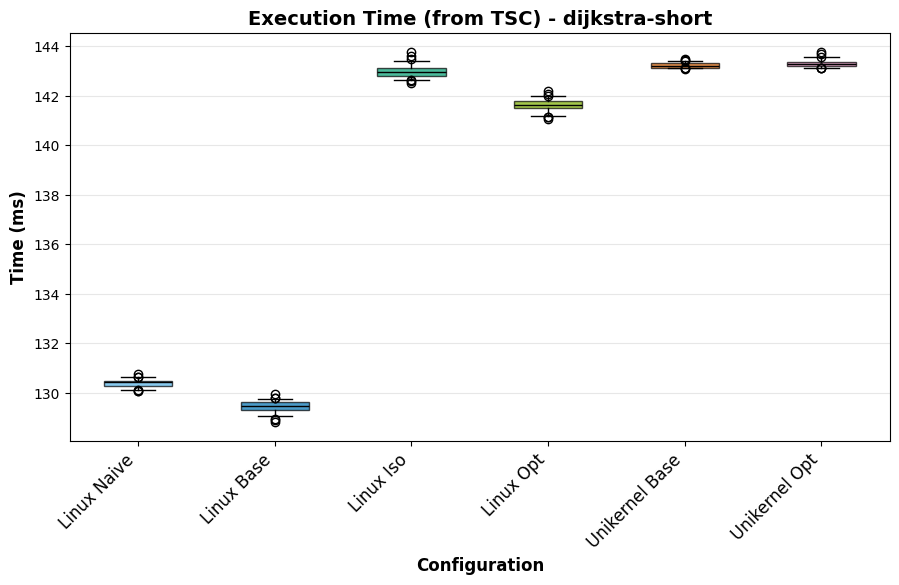


Medians for 'dijkstra':
  Linux Naive: 130.448732 ms
  Linux Base: 129.459685 ms
  Linux Iso: 142.981279 ms
  Linux Opt: 141.629354 ms
  Unikernel Base: 143.207680 ms
  Unikernel Opt: 143.288463 ms

Median range for 'dijkstra':
  Smallest: Linux Base: 129.459685 ms
  Largest:  Unikernel Opt: 143.288463 ms
  Difference: 10.68%

Saved: boxplots_short/time/boxplot_time_fdct.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1507758418.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


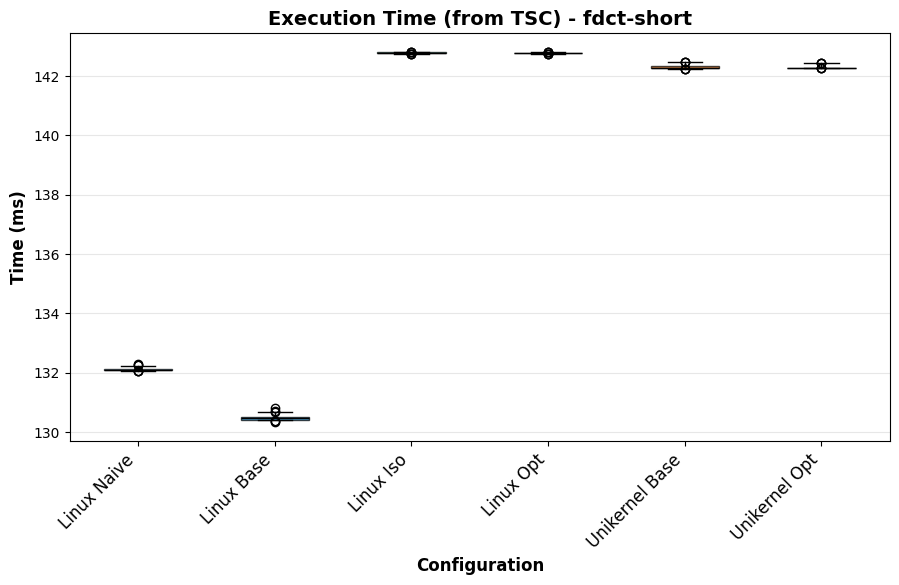


Medians for 'fdct':
  Linux Naive: 132.086745 ms
  Linux Base: 130.465295 ms
  Linux Iso: 142.776576 ms
  Linux Opt: 142.773800 ms
  Unikernel Base: 142.269454 ms
  Unikernel Opt: 142.269529 ms

Median range for 'fdct':
  Smallest: Linux Base: 130.465295 ms
  Largest:  Linux Iso: 142.776576 ms
  Difference: 9.44%

Saved: boxplots_short/time/boxplot_time_fir.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1507758418.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


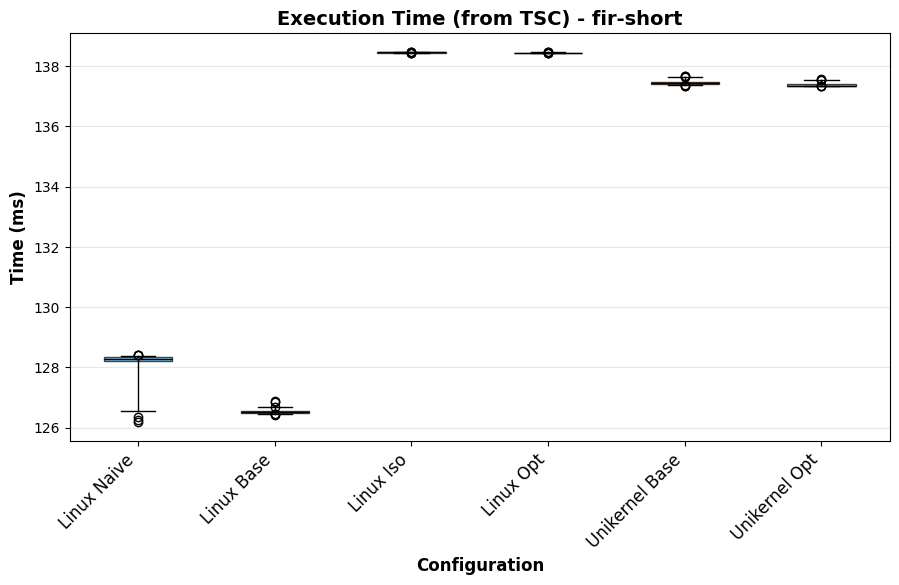


Medians for 'fir':
  Linux Naive: 128.271509 ms
  Linux Base: 126.513737 ms
  Linux Iso: 138.452755 ms
  Linux Opt: 138.434672 ms
  Unikernel Base: 137.448659 ms
  Unikernel Opt: 137.343586 ms

Median range for 'fir':
  Smallest: Linux Base: 126.513737 ms
  Largest:  Linux Iso: 138.452755 ms
  Difference: 9.44%



/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1507758418.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/time/boxplot_time_matmult-float.png


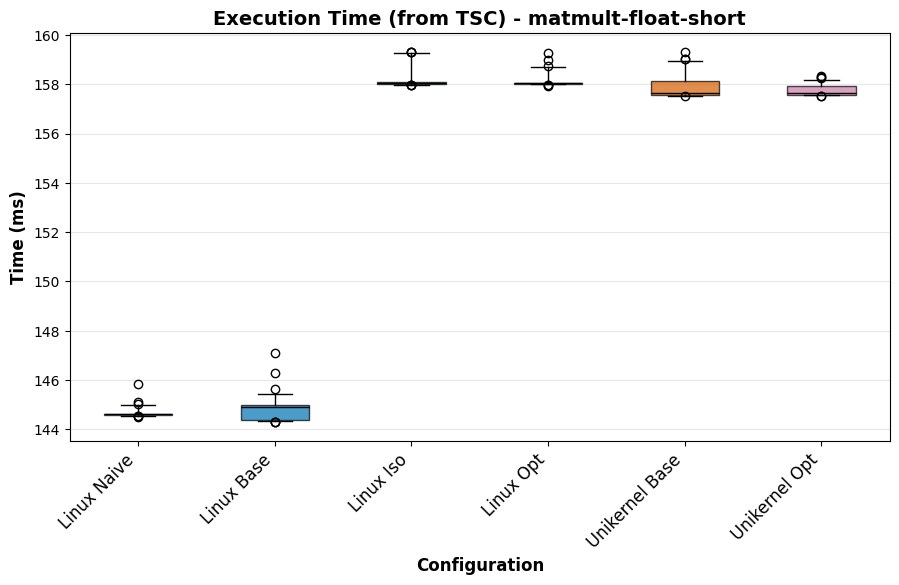


Medians for 'matmult-float':
  Linux Naive: 144.604879 ms
  Linux Base: 144.907978 ms
  Linux Iso: 158.033930 ms
  Linux Opt: 158.034477 ms
  Unikernel Base: 157.656479 ms
  Unikernel Opt: 157.656479 ms

Median range for 'matmult-float':
  Smallest: Linux Naive: 144.604879 ms
  Largest:  Linux Opt: 158.034477 ms
  Difference: 9.29%

Saved: boxplots_short/time/boxplot_time_matmult-int.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1507758418.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


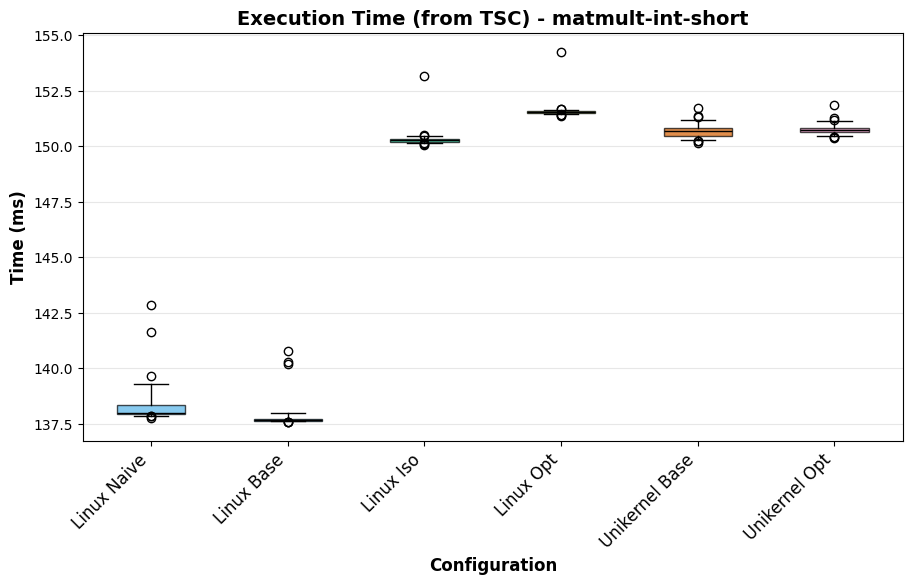


Medians for 'matmult-int':
  Linux Naive: 138.000773 ms
  Linux Base: 137.687579 ms
  Linux Iso: 150.280584 ms
  Linux Opt: 151.552638 ms
  Unikernel Base: 150.701177 ms
  Unikernel Opt: 150.758005 ms

Median range for 'matmult-int':
  Smallest: Linux Base: 137.687579 ms
  Largest:  Linux Opt: 151.552638 ms
  Difference: 10.07%



/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1507758418.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/time/boxplot_time_nettle-sha256.png


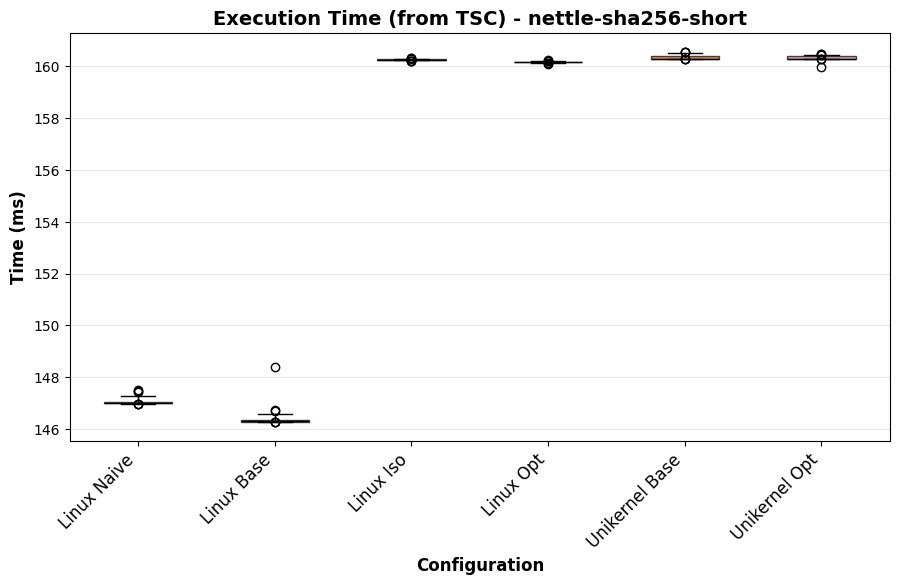


Medians for 'nettle-sha256':
  Linux Naive: 147.011713 ms
  Linux Base: 146.327491 ms
  Linux Iso: 160.259181 ms
  Linux Opt: 160.156489 ms
  Unikernel Base: 160.287208 ms
  Unikernel Opt: 160.287229 ms

Median range for 'nettle-sha256':
  Smallest: Linux Base: 146.327491 ms
  Largest:  Unikernel Opt: 160.287229 ms
  Difference: 9.54%

Saved: boxplots_short/time/boxplot_time_rijndael.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1507758418.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


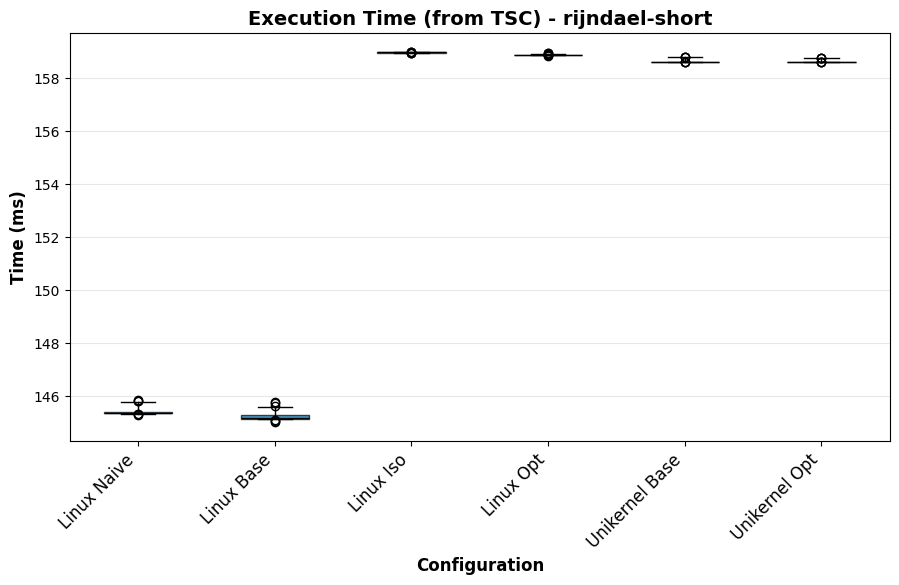


Medians for 'rijndael':
  Linux Naive: 145.358994 ms
  Linux Base: 145.161733 ms
  Linux Iso: 158.970082 ms
  Linux Opt: 158.874295 ms
  Unikernel Base: 158.614406 ms
  Unikernel Opt: 158.613822 ms

Median range for 'rijndael':
  Smallest: Linux Base: 145.161733 ms
  Largest:  Linux Iso: 158.970082 ms
  Difference: 9.51%


Coefficient of Variation (CV) for Execution Time


Configuration  Linux Base  Linux Iso  Linux Naive  Linux Opt  Unikernel Base  Unikernel Opt
Benchmark                                                                                  
crc32            0.055265   0.011624     0.204605   0.010226        0.046180       0.035140
cubic            0.130028   0.006910     0.085362   0.007458        0.050293       0.037216
dijkstra         0.185977   0.189643     0.125313   0.180920        0.075001       0.102505
fdct             0.073823   0.012754     0.048936   0.011697        0.048686       0.036479
fir              0.072634   0.006694     0.448906   0.008203        0.0

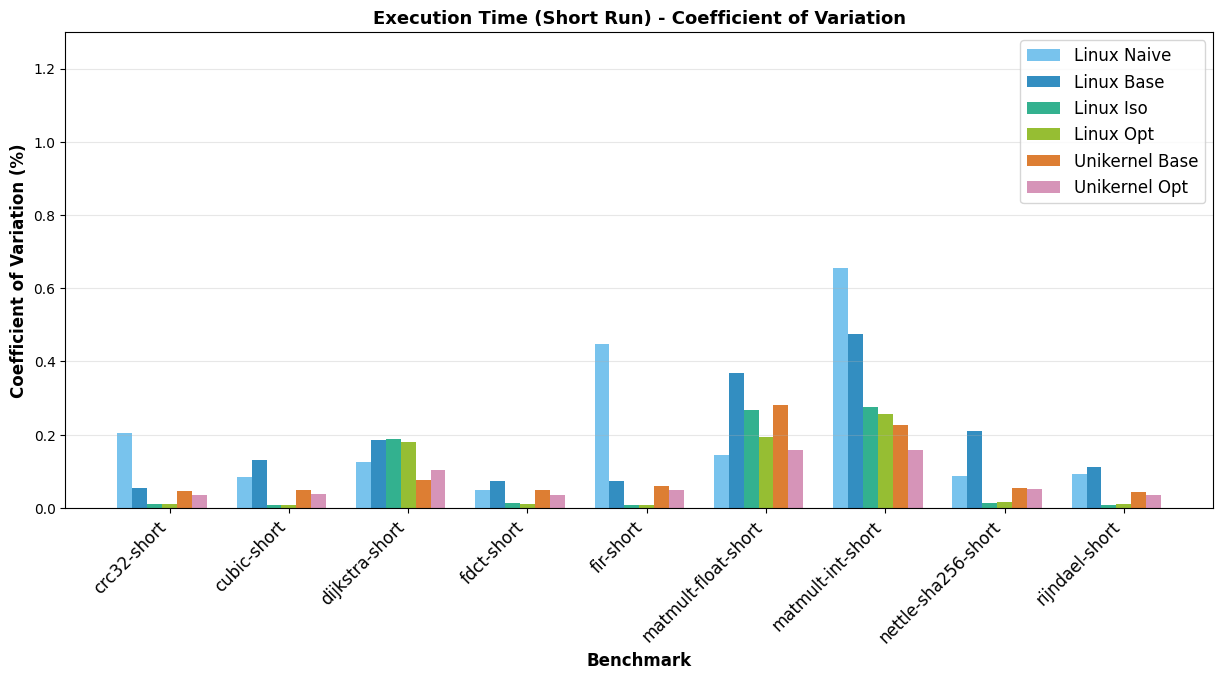

In [88]:
# Boxplot for execution time per benchmark
# One plot per benchmark, showing all configurations

# Get unique benchmarks
benchmarks = sorted([b for b in energy_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    'naive_linux',
    'base_linux',
    'linux_iso',
    'linux_optimized_wo_iso',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys()]

# Define colors matching ryddet_plots
config_colors = {
    'base_linux': '#0072B2',
    'naive_linux': '#56B4E9',
    'linux_iso': '#009E73',
    'linux_optimized_wo_iso': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    data_to_plot = []
    labels = []
    colors_to_use = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            time_ms = pc_bench['cpu_cycles'].values / 3.1e6
            data_to_plot.append(time_ms)
            labels.append(config_labels.get(config_name, config_name))
            colors_to_use.append(config_colors.get(config_name, '#7f7f7f'))
    
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))
        
        for patch, color in zip(bp['boxes'], colors_to_use):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Time (ms)', fontsize=12, fontweight='bold')
        ax.set_title(f'Execution Time (from TSC) - {benchmark}-short', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45, labelsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        
        plt.subplots_adjust(left=0.15, bottom=0.25, right=0.97, top=0.93)
        
        output_dir = Path('boxplots_short/time')
        output_dir.mkdir(parents=True, exist_ok=True)
        filename = output_dir / f'boxplot_time_{benchmark}.png'
        plt.savefig(filename, dpi=150)
        print(f"Saved: {filename}")
        
        plt.show()
        print(f"\nMedians for '{benchmark}':")
        for config_name, data in zip(configs, data_to_plot):
            median_val = np.median(data)
            label = config_labels.get(config_name, config_name)
            print(f"  {label}: {median_val:.6f} ms")
        print()
        medians = [(config_labels.get(config_name, config_name), np.median(data))
                   for config_name, data in zip(configs, data_to_plot)]
        if medians:
            min_label, min_median = min(medians, key=lambda x: x[1])
            max_label, max_median = max(medians, key=lambda x: x[1])
            pct_diff = ((max_median - min_median) / min_median) * 100
            print(f"Median range for '{benchmark}':")
            print(f"  Smallest: {min_label}: {min_median:.6f} ms")
            print(f"  Largest:  {max_label}: {max_median:.6f} ms")
            print(f"  Difference: {pct_diff:.2f}%\n")

print("\n" + "="*80)
print("Coefficient of Variation (CV) for Execution Time")
print("="*80)

time_cv_results = []

for config_name in configs:
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    
    for benchmark in benchmarks:
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 1:
            time_ms = pc_bench['cpu_cycles'].values / 3.1e6
            time_cv = (time_ms.std() / time_ms.mean()) * 100
        else:
            time_cv = None
        
        time_cv_results.append({
            'Configuration': config_labels.get(config_name, config_name),
            'Benchmark': benchmark,
            'CV (%)': time_cv
        })

time_cv_df = pd.DataFrame(time_cv_results)
time_cv_pivot = time_cv_df.pivot(index='Benchmark', columns='Configuration', values='CV (%)')

print("\n")
print(time_cv_pivot.to_string())
print("\n" + "="*80)

# CV bar plot
x = np.arange(len(benchmarks)) * 1.2
width = 0.15

fig_cv, ax_cv = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = time_cv_df[time_cv_df['Configuration'] == config_labels.get(config, config)]
    label = config_labels.get(config, config)

    time_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['Benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['CV (%)'].values[0]):
            time_cvs.append(bench_data['CV (%)'].values[0])
        else:
            time_cvs.append(0)

    offset = (i - len(configs)/2) * width
    ax_cv.bar(x + offset, time_cvs, width, label=label, color=config_colors.get(config, '#7f7f7f'), alpha=0.8)

ax_cv.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax_cv.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax_cv.set_title('Execution Time (Short Run) - Coefficient of Variation', fontsize=13, fontweight='bold')
ax_cv.set_xticks(x)
ax_cv.set_xticklabels([f'{b}-short' for b in benchmarks], rotation=45, ha='right', fontsize=12)
ax_cv.legend(fontsize=12)
ax_cv.set_ylim(top=1.3)
ax_cv.grid(axis='y', alpha=0.3)
plt.subplots_adjust(left=0.15, bottom=0.25, right=0.97, top=0.93)
plt.show()


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1378724781.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


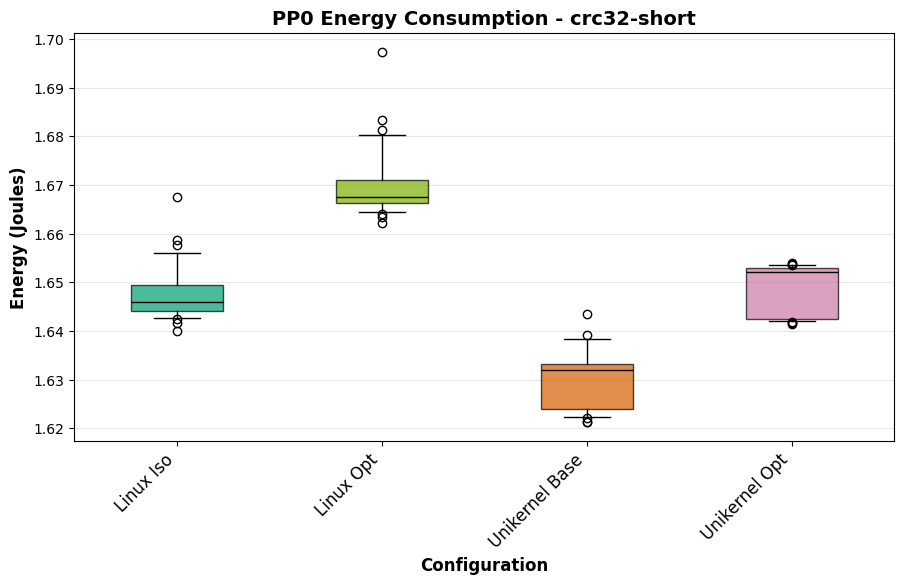

Saved: boxplots_short/pp0/boxplot_pp0_crc32.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1378724781.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


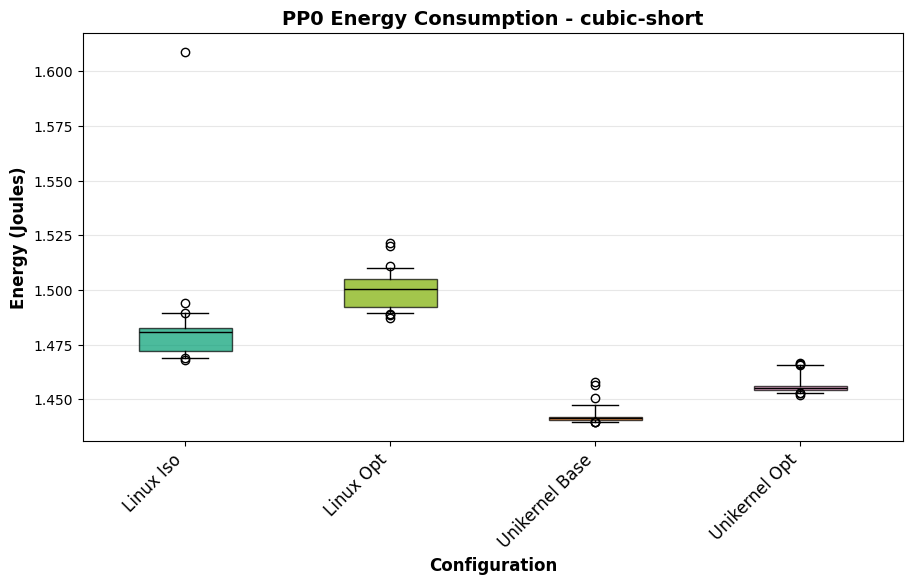

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1378724781.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots_short/pp0/boxplot_pp0_cubic.png


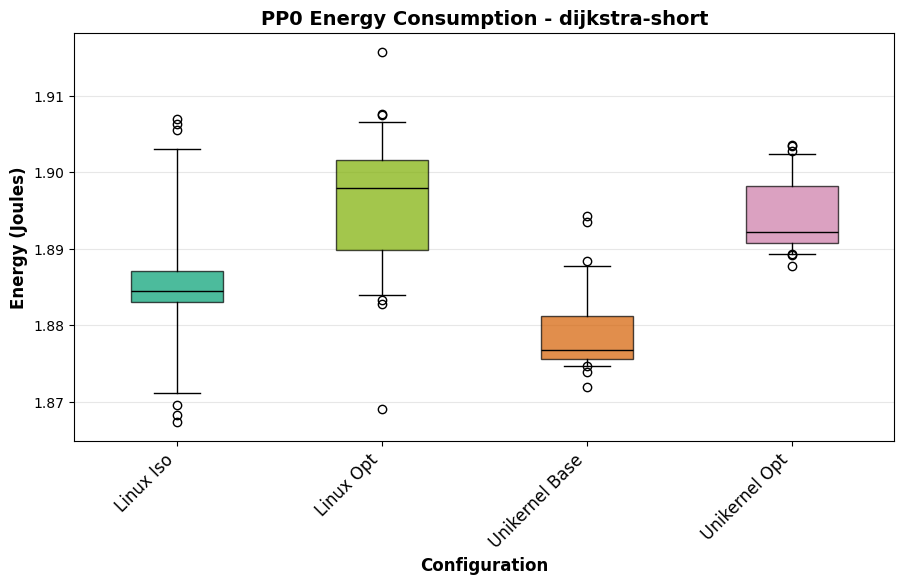

Saved: boxplots_short/pp0/boxplot_pp0_dijkstra.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1378724781.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


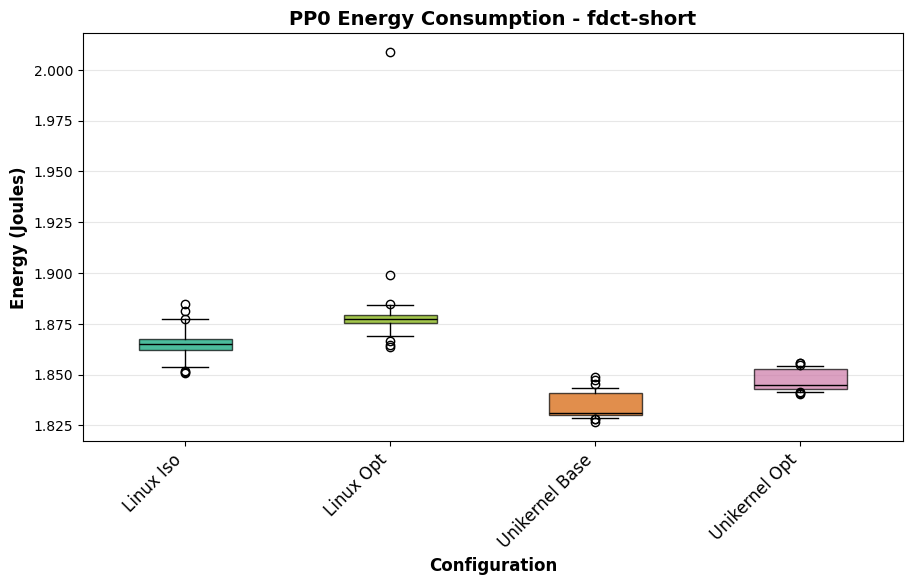

Saved: boxplots_short/pp0/boxplot_pp0_fdct.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1378724781.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


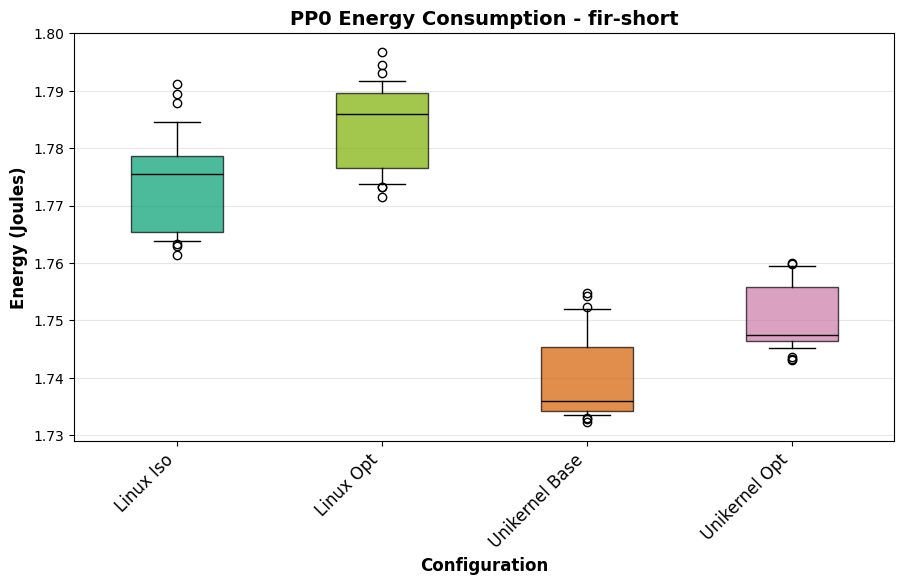

Saved: boxplots_short/pp0/boxplot_pp0_fir.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1378724781.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


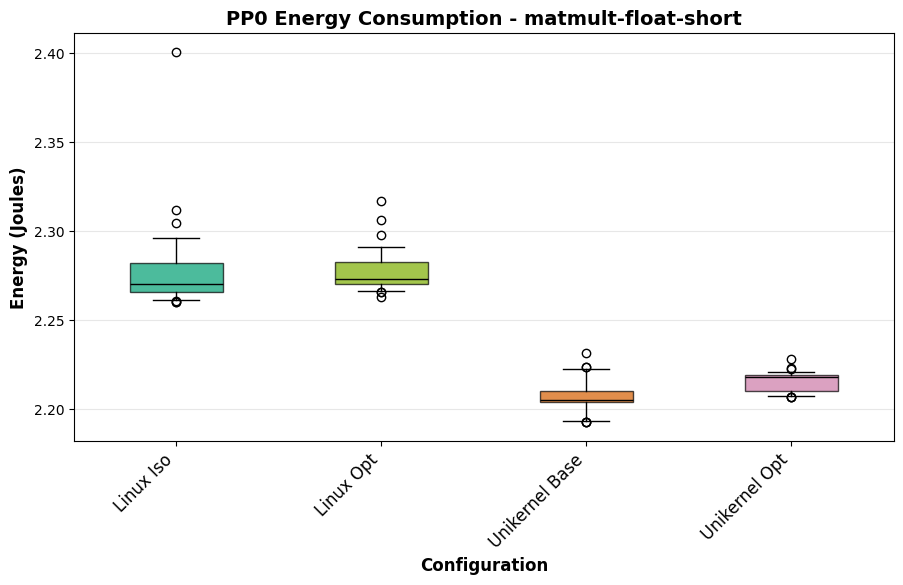

Saved: boxplots_short/pp0/boxplot_pp0_matmult-float.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1378724781.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


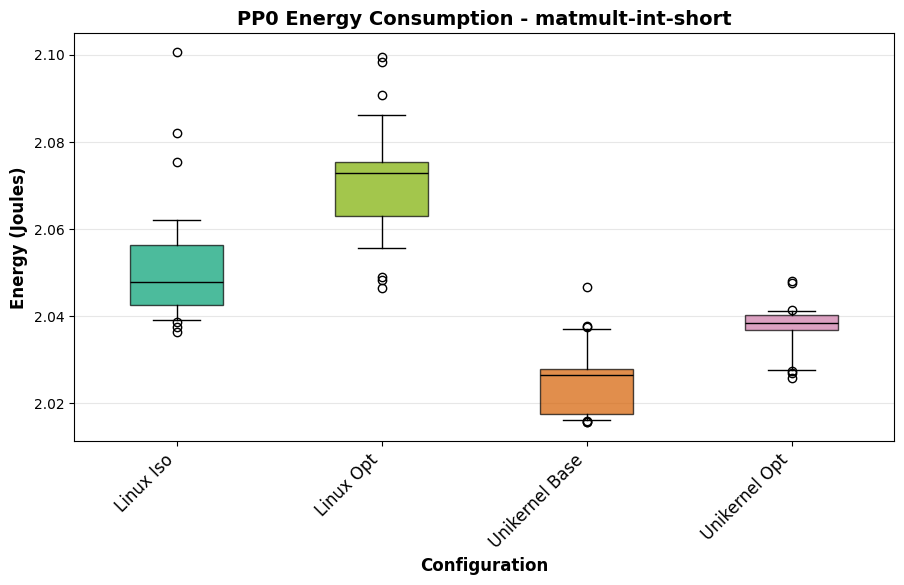

Saved: boxplots_short/pp0/boxplot_pp0_matmult-int.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1378724781.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


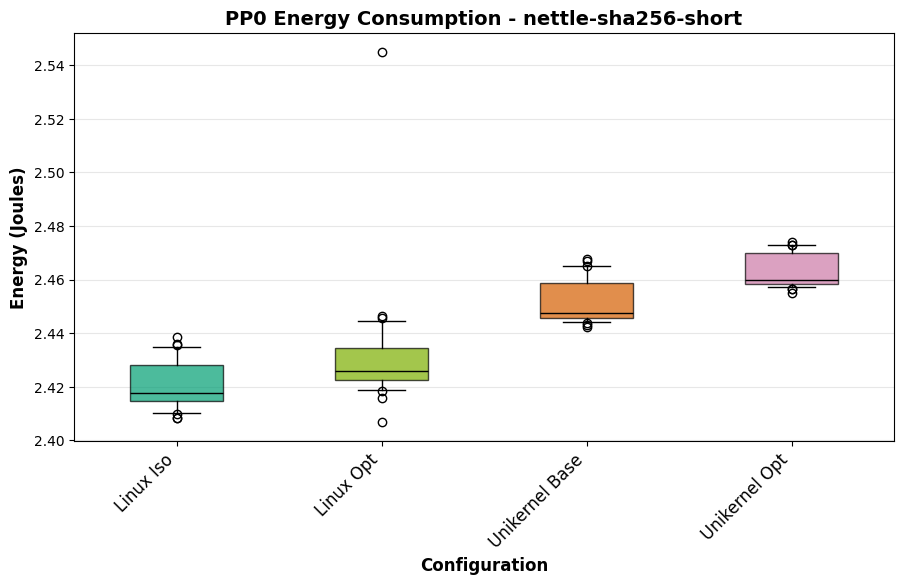

Saved: boxplots_short/pp0/boxplot_pp0_nettle-sha256.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_97490/1378724781.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


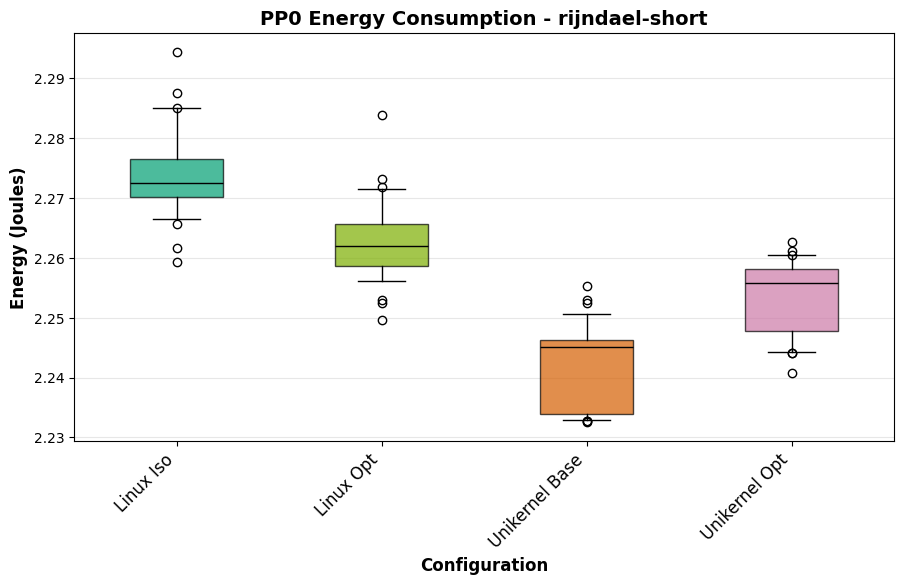

Saved: boxplots_short/pp0/boxplot_pp0_rijndael.png


In [81]:
# Boxplot for PP0 energy consumption per benchmark
# One plot per benchmark, showing all configurations

# Get unique benchmarks
benchmarks = sorted([b for b in energy_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    # 'naive_linux',
    # 'base_linux',
    'linux_iso',
    'linux_optimized_wo_iso',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys()]

# Define colors matching ryddet_plots
config_colors = {
    'base_linux': '#0072B2',
    'naive_linux': '#56B4E9',
    'linux_iso': '#009E73',
    'linux_optimized_wo_iso': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    colors_to_use = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            data_to_plot.append(pc_bench['pp0_joules'].values)
            labels.append(config_labels.get(config_name, config_name))
            colors_to_use.append(config_colors.get(config_name, '#7f7f7f'))
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))
        
        # Customize boxplot appearance
        for patch, color in zip(bp['boxes'], colors_to_use):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'PP0 Energy Consumption - {benchmark}-short', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45, labelsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        
        plt.subplots_adjust(left=0.15, bottom=0.25, right=0.97, top=0.93)


        

        # Create output directory and save figure
        output_dir = Path('boxplots_short/pp0')        
        output_dir.mkdir(parents=True, exist_ok=True)
        filename = output_dir / f'boxplot_pp0_{benchmark}.png'

        plt.savefig(filename, dpi=150)
        plt.show()
        print(f"Saved: {filename}")



In [82]:
# Calculate total execution time for each configuration
print("Total execution time per configuration:")
print("=" * 60)

for config_name in subdirs.keys():
    if config_name not in pc_data:
        print(f"{config_name}: No data available")
        continue
    
    pc_df = pc_data[config_name]
    
    # Sum all execution times
    total_time_ms = pc_df['cooldown_ms'].sum()
    total_time_s = total_time_ms / 1000
    total_time_min = total_time_s / 60
    
    # Count number of measurements
    num_measurements = len(pc_df)
    
    print(f"\n{config_name}:")
    print(f"  Total time: {total_time_ms:,.2f} ms ({total_time_s:,.2f} s / {total_time_min:,.2f} min)")
    print(f"  Number of measurements: {num_measurements}")
    print(f"  Average time per measurement: {total_time_ms/num_measurements:.2f} ms")

Total execution time per configuration:

base_linux:
  Total time: 816.08 ms (0.82 s / 0.01 min)
  Number of measurements: 450
  Average time per measurement: 1.81 ms

base_unikernel:
  Total time: 0.00 ms (0.00 s / 0.00 min)
  Number of measurements: 450
  Average time per measurement: 0.00 ms

naive_linux:
  Total time: 0.00 ms (0.00 s / 0.00 min)
  Number of measurements: 450
  Average time per measurement: 0.00 ms

linux_iso:
  Total time: 114.09 ms (0.11 s / 0.00 min)
  Number of measurements: 450
  Average time per measurement: 0.25 ms

linux_optimized_wo_iso:
  Total time: 340.32 ms (0.34 s / 0.01 min)
  Number of measurements: 450
  Average time per measurement: 0.76 ms

optimized_unikernel:
  Total time: 1,410.00 ms (1.41 s / 0.02 min)
  Number of measurements: 450
  Average time per measurement: 3.13 ms


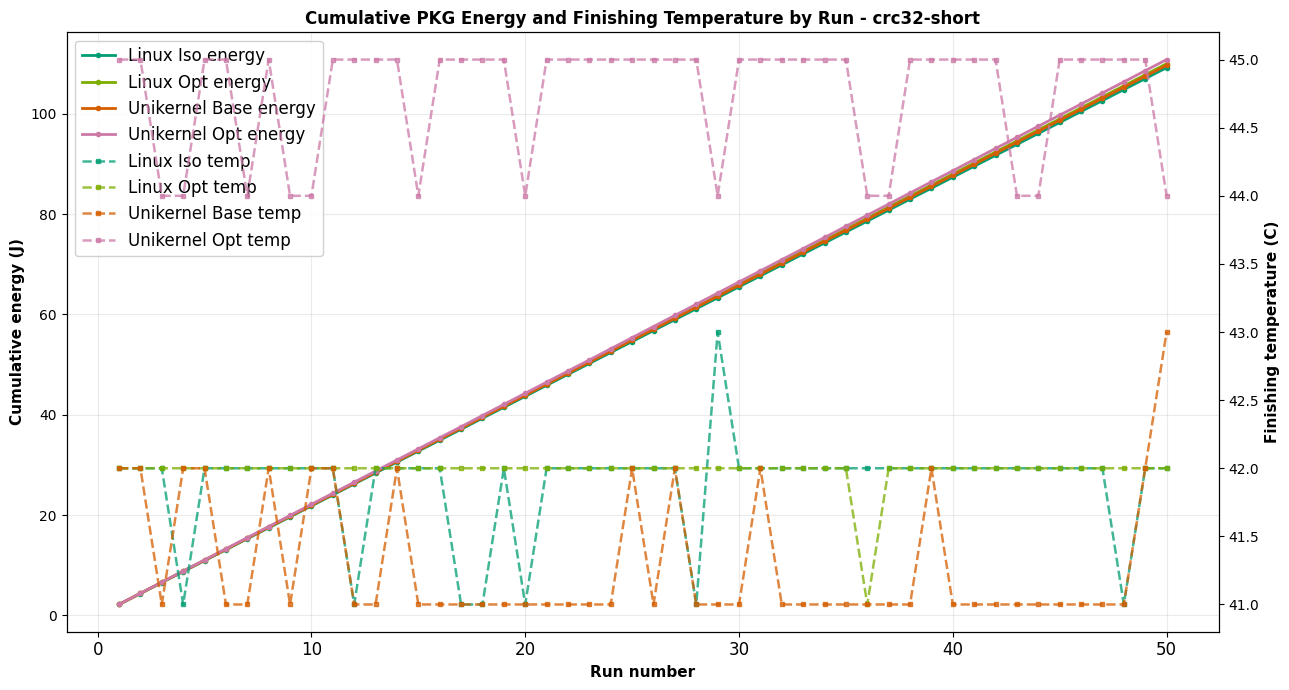

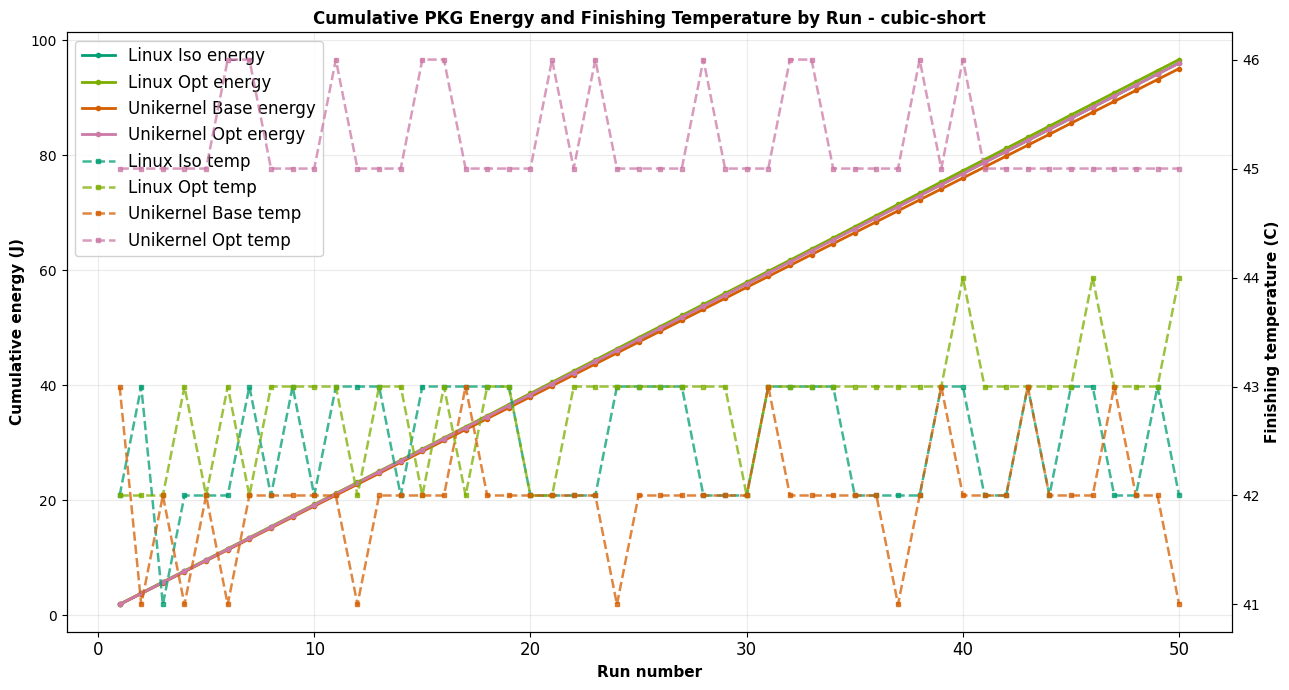

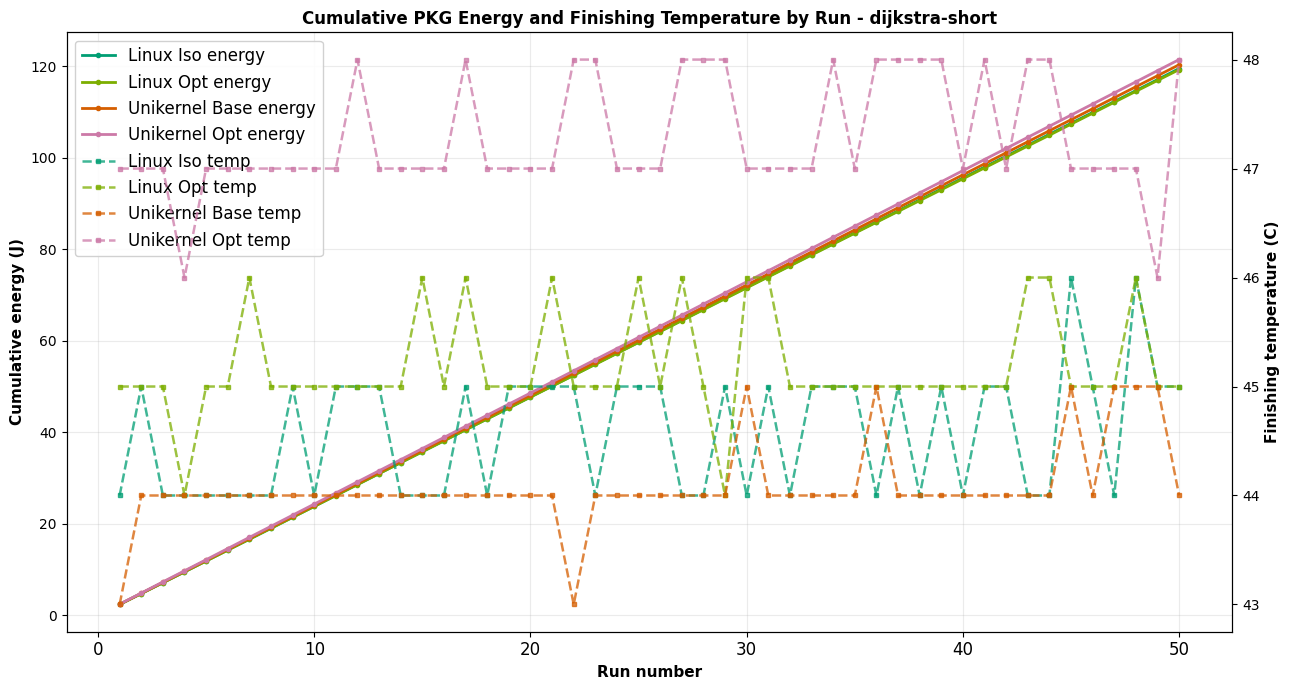

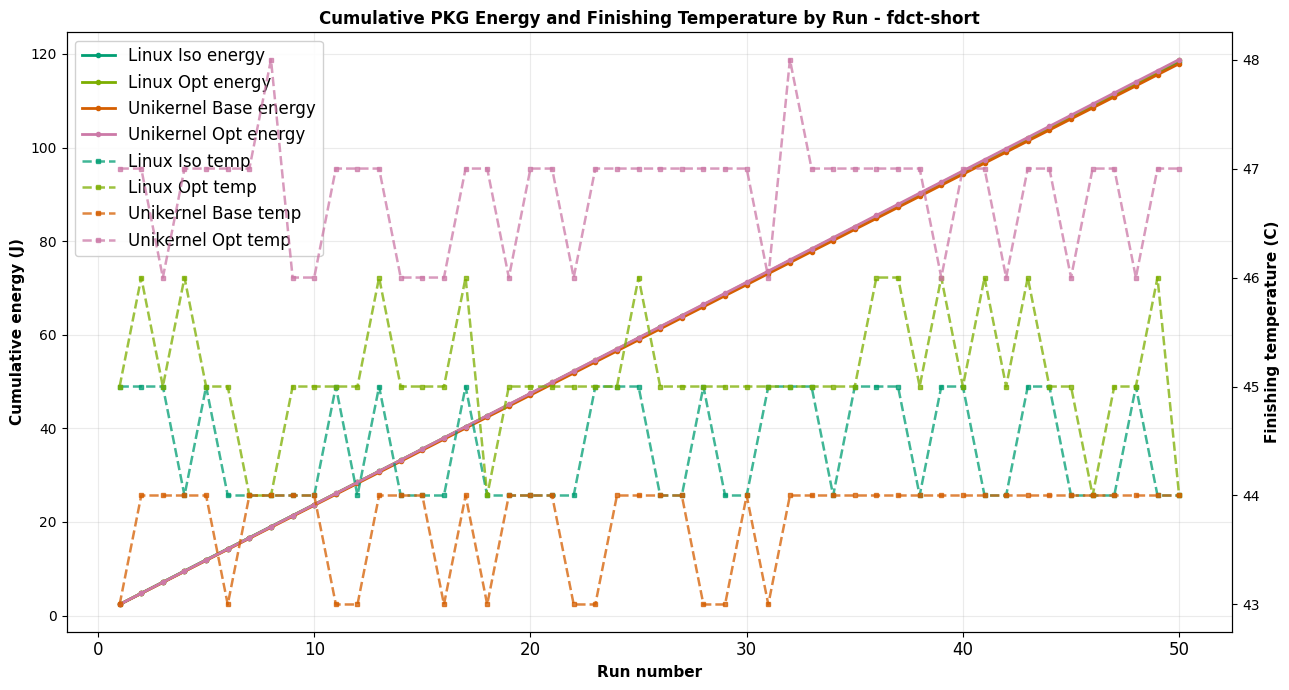

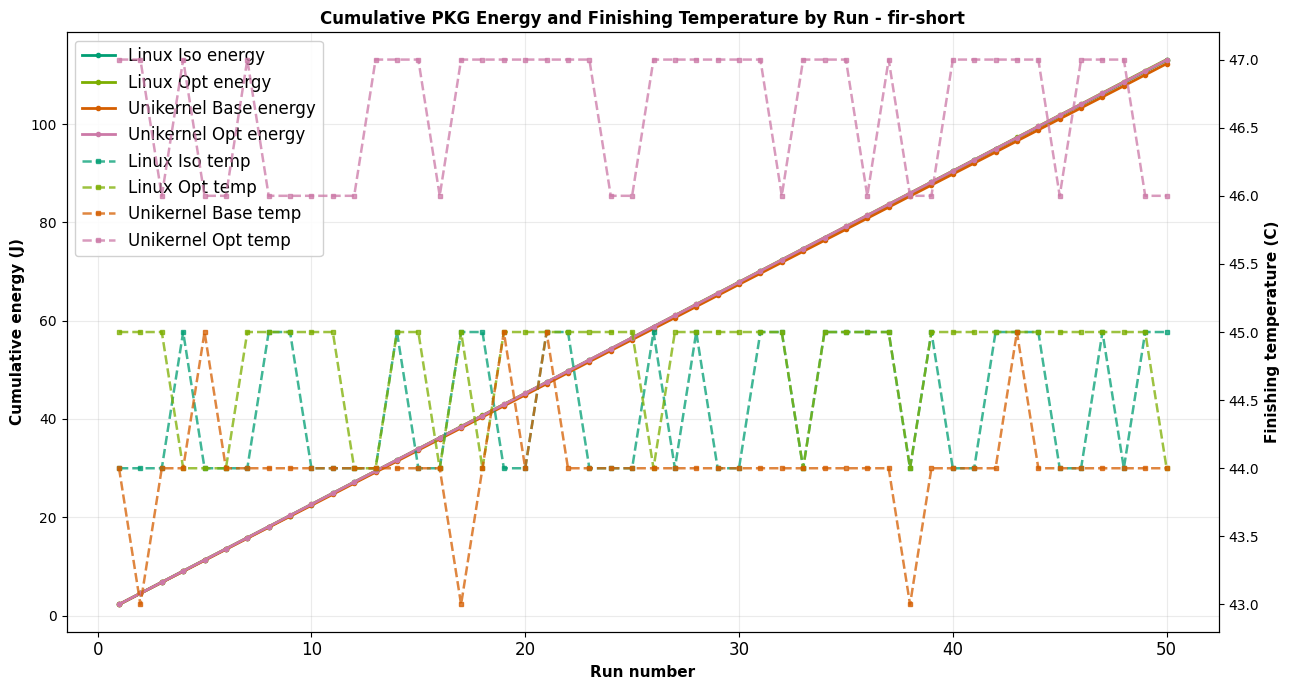

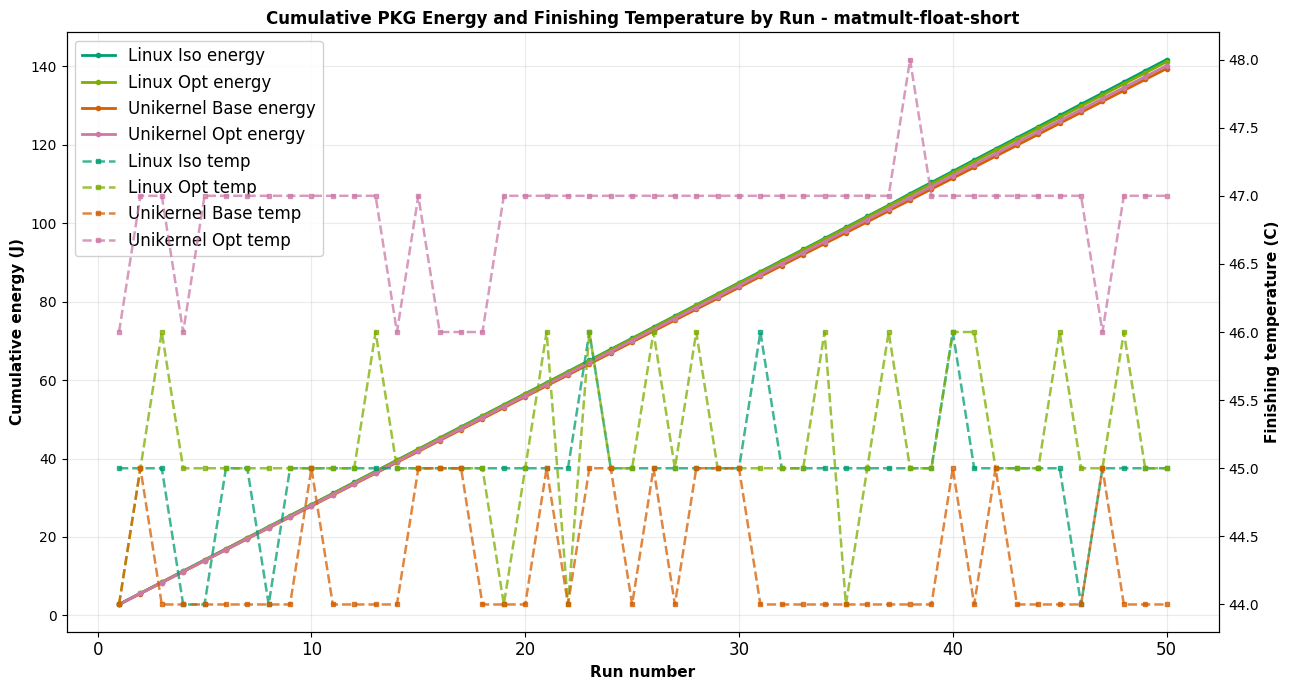

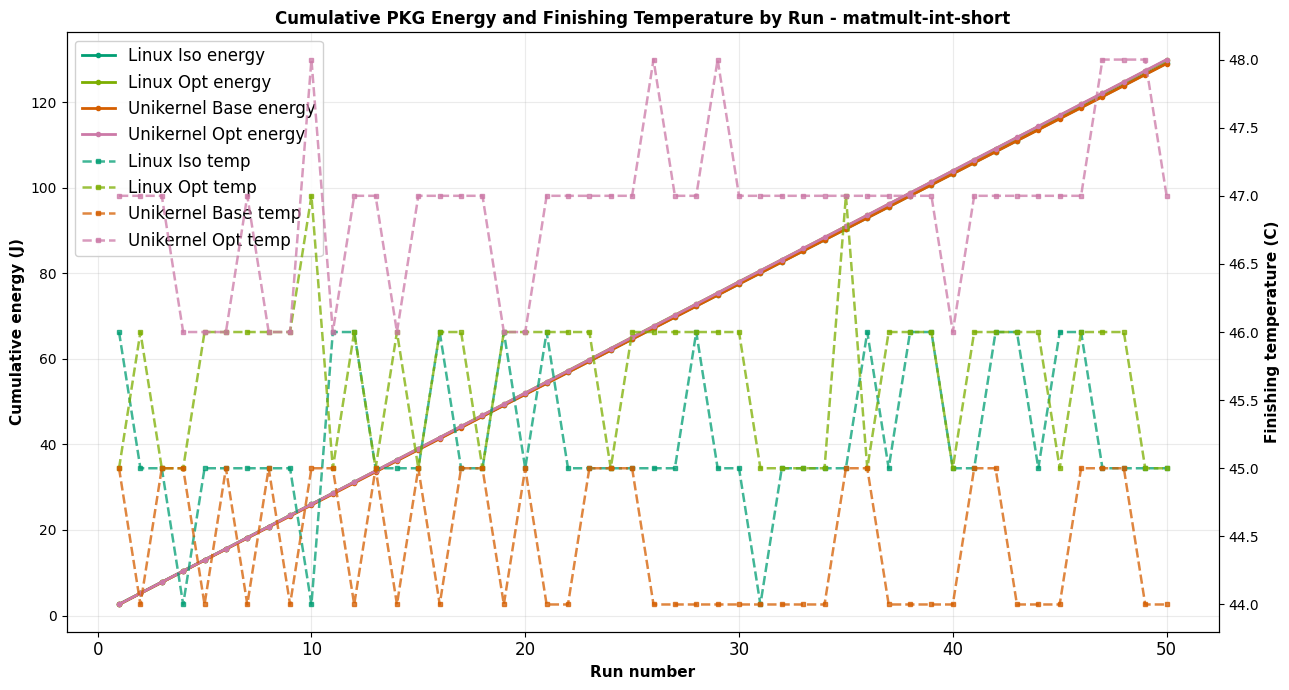

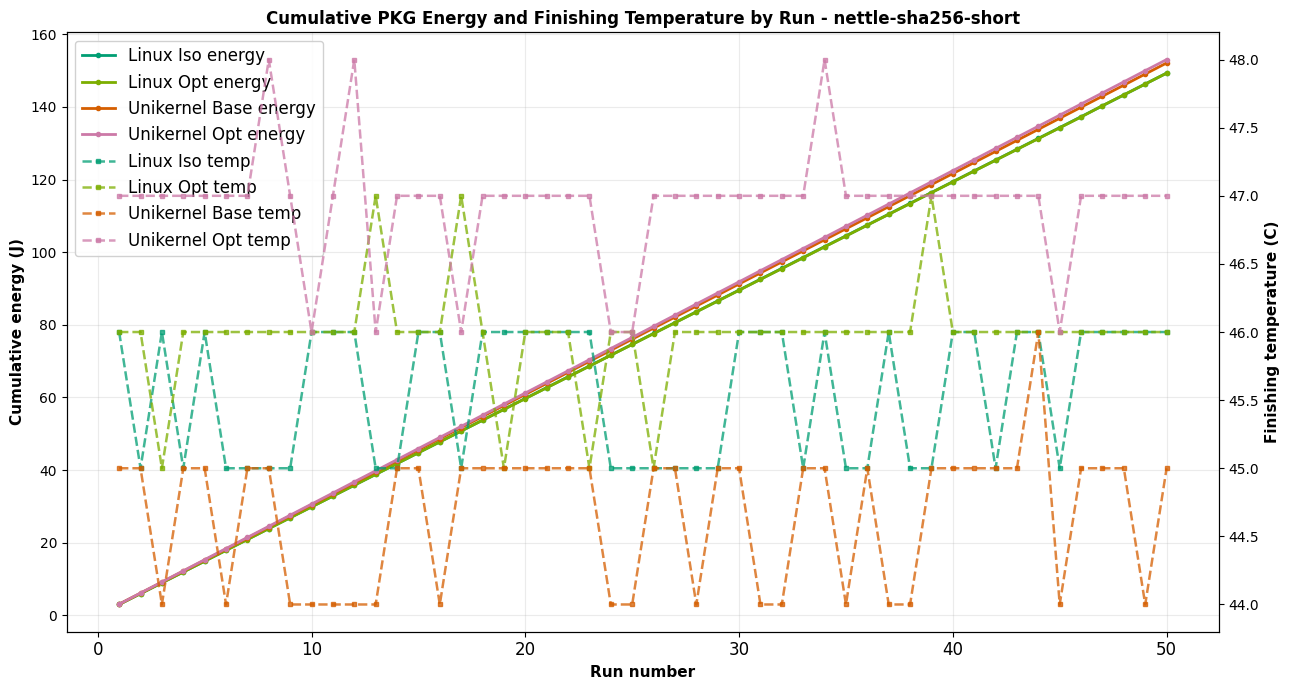

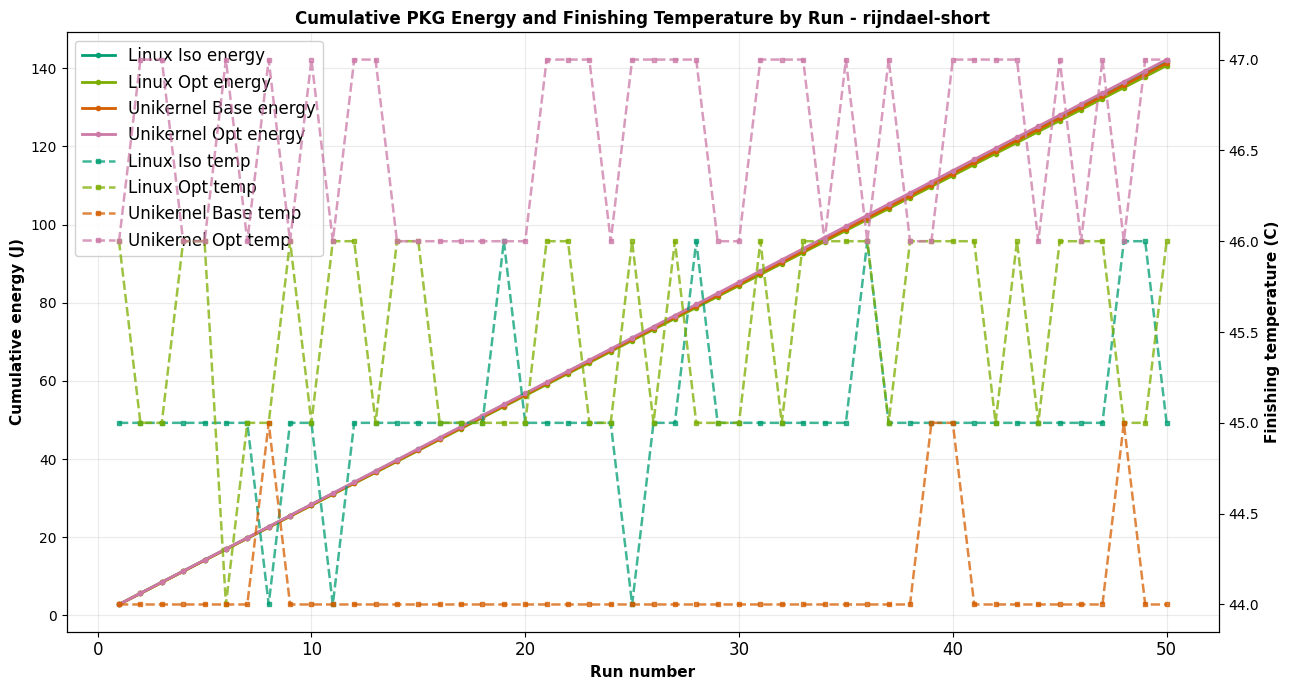

In [83]:
# Cumulative PKG energy by benchmark, with temperature shown on a second axis
if 'pc_data' not in globals() or not pc_data:
    print('pc_data is not loaded. Run the data-loading cells first.')
else:
    required = {'benchmark', 'pp0_joules'}
    temp_candidates = ['pkg_temp_after', 'temp_after']

    # Keep a consistent display order across all benchmark plots.
    config_order = [
        # 'naive_linux',
        # 'base_linux',
        'linux_iso',
        'linux_optimized_wo_iso',
        'base_unikernel',
        'optimized_unikernel'
    ]
    ordered_configs = [c for c in config_order if c in pc_data]
    remaining_configs = sorted([c for c in pc_data.keys() if c not in ordered_configs])
    all_configs = ordered_configs

    # Build benchmark list across all configs that have required columns.
    benchmark_set = set()
    for config_name in all_configs:
        pc_df = pc_data[config_name]
        if required.issubset(pc_df.columns):
            benchmark_set.update(pc_df['benchmark'].dropna().unique())
    benchmarks = sorted(benchmark_set)

    if not benchmarks:
        print('No benchmark data found with required columns.')
    else:
        for benchmark in benchmarks:
            fig, ax_energy = plt.subplots(figsize=(13, 7))
            ax_temp = ax_energy.twinx()
            energy_handles = []
            temp_handles = []
            any_energy_series = False
            any_temp_series = False

            for config_name in all_configs:
                pc_df = pc_data[config_name]
                if not required.issubset(pc_df.columns):
                    continue

                bench_df = pc_df[pc_df['benchmark'] == benchmark].reset_index(drop=True)
                if len(bench_df) == 0:
                    continue

                run_nr = np.arange(1, len(bench_df) + 1)
                cumulative_energy = bench_df['pkg_joules'].cumsum()
                line_color = config_colors.get(config_name, '#7f7f7f')
                display_name = config_labels.get(config_name, config_name)

                energy_line, = ax_energy.plot(
                    run_nr,
                    cumulative_energy,
                    linewidth=2.0,
                    marker='o',
                    markersize=3,
                    color=line_color,
                    label=f'{display_name} energy'
                )
                energy_handles.append(energy_line)
                any_energy_series = True

                temp_col = next((col for col in temp_candidates if col in bench_df.columns), None)
                if temp_col is not None:
                    temp_series = pd.to_numeric(bench_df[temp_col], errors='coerce')
                    if temp_series.notna().any():
                        temp_line, = ax_temp.plot(
                            run_nr,
                            temp_series,
                            linewidth=1.8,
                            linestyle='--',
                            marker='s',
                            markersize=3,
                            color=line_color,
                            alpha=0.75,
                            label=f'{display_name} temp'
                        )
                        temp_handles.append(temp_line)
                        any_temp_series = True

            if not any_energy_series:
                plt.close(fig)
                print(f'No data to plot for benchmark: {benchmark}')
                continue

            ax_energy.set_xlabel('Run number', fontsize=11, fontweight='bold')
            ax_energy.tick_params(axis='x', labelsize=12)
            ax_energy.set_ylabel('Cumulative energy (J)', fontsize=11, fontweight='bold')
            ax_temp.set_ylabel('Finishing temperature (C)', fontsize=11, fontweight='bold')
            ax_energy.set_title(
                f'Cumulative PKG Energy and Finishing Temperature by Run - {benchmark}-short',
                fontsize=12,
                fontweight='bold'
            )
            ax_energy.grid(alpha=0.25)
            handles = energy_handles + temp_handles
            if handles:
                ax_energy.legend(handles, [handle.get_label() for handle in handles], loc='upper left', fontsize=12, framealpha=0.9)
            if not any_temp_series:
                ax_temp.set_ylabel('Finishing temperature (C)', fontsize=11, fontweight='bold')

            plt.tight_layout()
            plt.show()

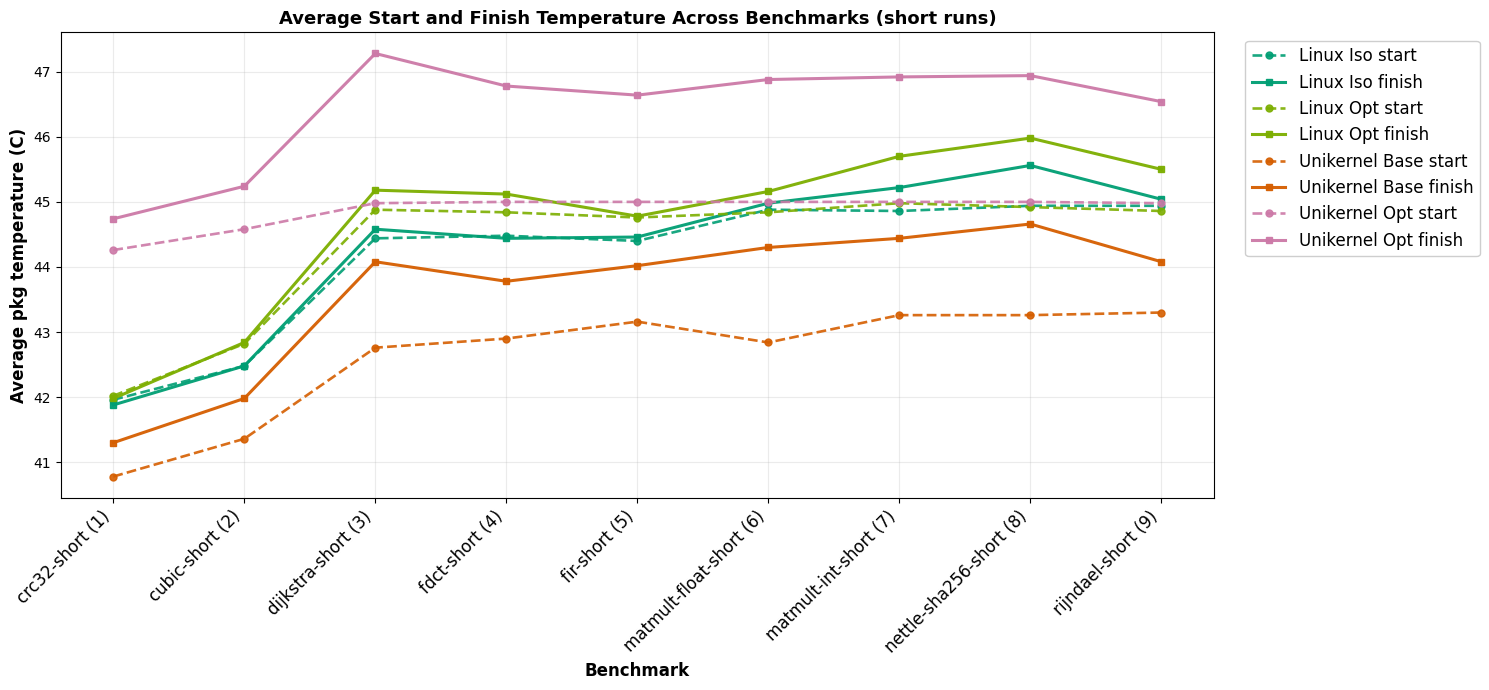

In [90]:
# Average start/finish temperature per benchmark in a single plot (hue = configuration)
if 'pc_data' not in globals() or not pc_data:
    print('pc_data is not loaded. Run the data-loading cells first.')
else:
    start_temp_candidates = ['pkg_temp_before']
    finish_temp_candidates = ['pkg_temp_after']

    preferred_order = [
        # 'naive_linux',
        # 'base_linux',
        'linux_iso',
        'linux_optimized_wo_iso',
        'base_unikernel',
        'optimized_unikernel'
    ]

    # Only plot configurations explicitly listed in preferred_order.
    ordered_configs = [c for c in preferred_order if c in pc_data]

    rows = []
    for config_name in ordered_configs:
        pc_df = pc_data.get(config_name)
        if pc_df is None or 'benchmark' not in pc_df.columns:
            continue

        start_col = next((col for col in start_temp_candidates if col in pc_df.columns), None)
        finish_col = next((col for col in finish_temp_candidates if col in pc_df.columns), None)
        if start_col is None and finish_col is None:
            continue

        for benchmark, group in pc_df.groupby('benchmark', sort=True):
            entry = {'config': config_name, 'benchmark': benchmark}
            if start_col is not None:
                entry['avg_start_temp'] = pd.to_numeric(group[start_col], errors='coerce').mean()
            if finish_col is not None:
                entry['avg_finish_temp'] = pd.to_numeric(group[finish_col], errors='coerce').mean()
            rows.append(entry)

    temp_avg_df = pd.DataFrame(rows)
    if temp_avg_df.empty:
        print('No usable temperature columns were found for plotting.')
    else:
        benchmarks = sorted(temp_avg_df['benchmark'].dropna().unique())
        x = np.arange(len(benchmarks))

        if 'config_colors' not in globals():
            config_colors = {}

        fig, ax = plt.subplots(figsize=(15, 7))
        for config_name in ordered_configs:
            config_df = temp_avg_df[temp_avg_df['config'] == config_name]
            if config_df.empty:
                continue

            aligned = config_df.set_index('benchmark').reindex(benchmarks)
            color = config_colors.get(config_name, '#7f7f7f')
            display_name = config_labels.get(config_name, config_name) if 'config_labels' in globals() else config_name

            start_vals = aligned['avg_start_temp'].to_numpy() if 'avg_start_temp' in aligned.columns else np.array([])
            finish_vals = aligned['avg_finish_temp'].to_numpy() if 'avg_finish_temp' in aligned.columns else np.array([])

            if start_vals.size and np.isfinite(start_vals).any():
                ax.plot(
                    x,
                    start_vals,
                    linestyle='--',
                    marker='o',
                    linewidth=1.9,
                    markersize=5,
                    color=color,
                    alpha=0.9,
                    label=f'{display_name} start'
                )

            if finish_vals.size and np.isfinite(finish_vals).any():
                ax.plot(
                    x,
                    finish_vals,
                    linestyle='-',
                    marker='s',
                    linewidth=2.2,
                    markersize=5,
                    color=color,
                    alpha=0.95,
                    label=f'{display_name} finish'
                )

        ax.set_xticks(x)
        ax.set_xticklabels([f'{benchmarks[i]}-short ({i + 1})' for i in range(9)], rotation=45, ha='right', fontsize=12)
        ax.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
        ax.set_ylabel('Average pkg temperature (C)', fontsize=12, fontweight='bold')
        ax.set_title('Average Start and Finish Temperature Across Benchmarks (short runs)', fontsize=13, fontweight='bold')
        ax.grid(alpha=0.25)
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, framealpha=0.95)
        plt.tight_layout()
        plt.show()

In [85]:
# Energy per repetition tables (one table per configuration)
# Run after data-loading cells (pc_data and powermeter_data) are available.

if 'pc_data' not in globals() or not pc_data:
    print('pc_data is not loaded. Run the data-loading cells first.')
elif 'powermeter_data' not in globals():
    print('powermeter_data is not loaded. Run the data-loading cells first.')
else:
    repeat_short = {
        'crc32': 50000,
        'cubic': 50000,
        'dijkstra': 3000,
        'fdct': 930000,
        'fir': 5200,
        'matmult-float': 390000,
        'matmult-int': 48000,
        'nettle-sha256': 180000,
        'rijndael': 1900,
    }
    repeat_long = {
        'crc32': 6000000,
        'cubic': 6000000,
        'dijkstra': 400000,
        'fdct': 100000000,
        'fir': 500000,
        'matmult-float': 40000000,
        'matmult-int': 5000000,
        'nettle-sha256': 20000000,
        'rijndael': 200000,
    }

    subdir_strings = [str(p).lower() for p in subdirs.values()] if 'subdirs' in globals() else []
    if any('short' in s for s in subdir_strings):
        repeat_map = repeat_short
        repeat_variant = 'short'
    elif any('long' in s for s in subdir_strings):
        repeat_map = repeat_long
        repeat_variant = 'long'
    else:
        repeat_map = repeat_short
        repeat_variant = 'short (default)'

    rows = []
    for config_name, pc_df in pc_data.items():
        if 'benchmark' not in pc_df.columns or 'cpu_cycles' not in pc_df.columns:
            continue

        for benchmark, group in pc_df.groupby('benchmark', sort=True):
            repeat_count = repeat_map.get(benchmark)
            if not repeat_count or repeat_count <= 0:
                continue

            pkg_mean = pd.to_numeric(group['pkg_joules'], errors='coerce').mean() if 'pkg_joules' in group.columns else np.nan
            pp0_mean = pd.to_numeric(group['pp0_joules'], errors='coerce').mean() if 'pp0_joules' in group.columns else np.nan

            pm_vals = []
            pm_bench = powermeter_data.get(config_name, {}).get(benchmark, {})
            cpu_cycles = pd.to_numeric(group['cpu_cycles'], errors='coerce').to_numpy()
            for iteration, pm_df in pm_bench.items():
                if iteration >= len(cpu_cycles) or len(pm_df) < 2 or 'active_power (mW)' not in pm_df.columns:
                    continue
                cycles = cpu_cycles[iteration]
                if not np.isfinite(cycles):
                    continue
                avg_power_w = pd.to_numeric(pm_df['active_power (mW)'], errors='coerce').mean() / 1000.0
                time_s = cycles / 3.1e9
                pm_vals.append(avg_power_w * time_s)

            pm_mean = float(np.mean(pm_vals)) if pm_vals else np.nan

            rows.append({
                'Configuration': config_labels.get(config_name, config_name) if 'config_labels' in globals() else config_name,
                'Benchmark': benchmark,
                'Repeat Count': repeat_count,
                'PP0 per rep (J)': pp0_mean / repeat_count if np.isfinite(pp0_mean) else np.nan,
                'PKG per rep (J)': pkg_mean / repeat_count if np.isfinite(pkg_mean) else np.nan,
                'Powermeter per rep (J)': pm_mean / repeat_count if np.isfinite(pm_mean) else np.nan,
            })

    per_rep_df = pd.DataFrame(rows)
    if per_rep_df.empty:
        print('No rows produced. Check benchmark names and loaded data.')
    else:
        per_rep_df = per_rep_df.sort_values(['Configuration', 'Benchmark']).reset_index(drop=True)
        print(f'Energy per repetition ({repeat_variant} repeats)')

        for config_name in per_rep_df['Configuration'].dropna().unique():
            cfg_df = per_rep_df[per_rep_df['Configuration'] == config_name][[
                'Benchmark', 'Repeat Count', 'PP0 per rep (J)', 'PKG per rep (J)', 'Powermeter per rep (J)'
            ]].copy()

            print('\n' + '=' * 100)
            print(f'{config_name}')
            print('=' * 100)
            print(cfg_df.to_string(index=False, float_format=lambda x: f'{x:.5g}'))

Energy per repetition (short repeats)

Linux Base
    Benchmark  Repeat Count  PP0 per rep (J)  PKG per rep (J)  Powermeter per rep (J)
        crc32         50000       3.9672e-05       4.9274e-05              0.00013142
        cubic         50000       3.5672e-05       4.3542e-05               0.0001084
     dijkstra          3000       0.00074847        0.0008965               0.0021342
         fdct        930000       2.3915e-06       2.8741e-06              6.7601e-06
          fir          5200       0.00040712       0.00049071               0.0011705
matmult-float        390000       6.9396e-06       8.2209e-06              1.8208e-05
  matmult-int         48000       5.0922e-05       6.0836e-05              0.00013972
nettle-sha256        180000       1.5958e-05       1.8779e-05              4.0043e-05
     rijndael          1900        0.0014085        0.0016745               0.0037376

Linux Iso
    Benchmark  Repeat Count  PP0 per rep (J)  PKG per rep (J)  Powermeter per r

In [86]:
from scipy.stats import mannwhitneyu
from itertools import combinations
import pandas as pd
import numpy as np

# Perform Mann-Whitney U test to find non-significant differences
# A p-value > 0.05 is often considered not statistically significant.
p_value_threshold = 0.05

# Define the domains to test
domains = {
    'PKG Energy': 'pkg_joules',
    'PP0 Energy': 'pp0_joules',
    'Execution Time': 'cpu_cycles', # Will be converted to ms
    'Powermeter Energy': 'powermeter_energy' # Special handling
}

# Use the same configurations as the boxplots
config_order = [
    'linux_iso',
    'linux_optimized_wo_iso',
    'base_unikernel',
    'optimized_unikernel'
]
configs_to_compare = [c for c in config_order if c in pc_data]

# Get all unique benchmarks from the selected configs, ensuring they are strings
all_benchmarks = set()
for config_name in configs_to_compare:
    if config_name in pc_data:
        benchmarks_series = pc_data[config_name]['benchmark'].dropna()
        string_benchmarks = benchmarks_series[benchmarks_series.apply(lambda x: isinstance(x, str))]
        all_benchmarks.update(string_benchmarks.unique())

benchmarks = sorted(list(all_benchmarks))

print("Non-Significant Differences (p > 0.05) using Mann-Whitney U Test:")
print("="*80)

for domain_label, domain_key in domains.items():
    print(f"\n----- Domain: {domain_label} -----")
    non_significant_results = []

    for benchmark in benchmarks:
        for config1, config2 in combinations(configs_to_compare, 2):

            data1, data2 = None, None

            try:
                # Special handling for powermeter data
                if domain_key == 'powermeter_energy':
                    if config1 in powermeter_data and benchmark in powermeter_data[config1]:
                        energies1 = []
                        pc_bench1 = pc_data[config1][pc_data[config1]['benchmark'] == benchmark]
                        for it, pm_df in powermeter_data[config1][benchmark].items():
                            if len(pm_df) > 1 and it < len(pc_bench1):
                                time_s = pc_bench1.iloc[it]['cpu_cycles'] / 3.1e9
                                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                                energies1.append(avg_power_w * time_s)
                        data1 = pd.Series(energies1)

                    if config2 in powermeter_data and benchmark in powermeter_data[config2]:
                        energies2 = []
                        pc_bench2 = pc_data[config2][pc_data[config2]['benchmark'] == benchmark]
                        for it, pm_df in powermeter_data[config2][benchmark].items():
                            if len(pm_df) > 1 and it < len(pc_bench2):
                                time_s = pc_bench2.iloc[it]['cpu_cycles'] / 3.1e9
                                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                                energies2.append(avg_power_w * time_s)
                        data2 = pd.Series(energies2)

                # Handling for pc_data domains
                else:
                    if config1 in pc_data:
                        data1 = pc_data[config1][pc_data[config1]['benchmark'] == benchmark][domain_key]
                    if config2 in pc_data:
                        data2 = pc_data[config2][pc_data[config2]['benchmark'] == benchmark][domain_key]

                # Perform test if both datasets are valid
                if data1 is not None and data2 is not None and not data1.empty and not data2.empty:
                    if domain_key == 'cpu_cycles':
                        data1 = data1 / 3.1e6
                        data2 = data2 / 3.1e6

                    stat, p_value = mannwhitneyu(data1, data2, alternative='two-sided')

                    if p_value > p_value_threshold:
                        non_significant_results.append({
                            'Benchmark': benchmark,
                            'Config 1': config_labels.get(config1, config1),
                            'Config 2': config_labels.get(config2, config2),
                            'P-Value': p_value
                        })

            except Exception as e:
                pass

    if non_significant_results:
        results_df = pd.DataFrame(non_significant_results)
        print(results_df.to_string(index=False))
    else:
        print("No non-significant differences found.")


Non-Significant Differences (p > 0.05) using Mann-Whitney U Test:

----- Domain: PKG Energy -----
    Benchmark  Config 1       Config 2  P-Value
        cubic Linux Iso  Unikernel Opt 0.293107
     dijkstra Linux Iso      Linux Opt 0.255335
         fdct Linux Opt  Unikernel Opt 0.076437
          fir Linux Opt  Unikernel Opt 0.882170
  matmult-int Linux Iso Unikernel Base 0.666567
  matmult-int Linux Opt  Unikernel Opt 0.118409
nettle-sha256 Linux Iso      Linux Opt 0.134659

----- Domain: PP0 Energy -----
    Benchmark  Config 1      Config 2  P-Value
        crc32 Linux Iso Unikernel Opt 0.727733
matmult-float Linux Iso     Linux Opt 0.112055

----- Domain: Execution Time -----
    Benchmark       Config 1      Config 2  P-Value
        crc32 Unikernel Base Unikernel Opt 0.852339
        cubic Unikernel Base Unikernel Opt 0.196152
         fdct      Linux Iso     Linux Opt 0.336206
         fdct Unikernel Base Unikernel Opt 0.795999
matmult-float      Linux Iso     Linux Opt 0.9258